# 1D L2 Inversion with real data 

Workflow to do L2 inversion in real line data

In [2]:
# SimPEG functionality
import simpeg.electromagnetics.frequency_domain as fdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TensorMesh

# Common Python functionality
import os
import numpy as np
import pandas as pd
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import ipywidgets
import dill
%matplotlib inline
mpl.rcParams.update({"font.size": 12})

#Import helper functions
import sys
import data_functions, inversion_functions, l2_inversion, sparse_inversion


# Read the data:

Read from csv file of block 53:

In [4]:
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()

# Move one level up to the parent directory
parent_dir = os.path.dirname(current_dir)

# Construct the full path to the CSV file in the parent directory
csv_path = os.path.join(parent_dir, "block53_fdem_inv.csv")

fdem_data = pd.read_csv(csv_path) ## Set to the position of the csv_files list where the database you want is
pd.set_option('display.max_columns', len(fdem_data.columns))
fdem_data.head()

,x_tx,y_tx,gpsz_tx,altlas_bird,altlas_bird_derot,altrad_heli,bird_pitch,bird_roll,bird_yaw,Block,cp40k_reim,cp140k_reim,cp400_reim,cp1800_reim,cp8200_reim,cpi40k,cpi140k,cpi400,cpi1800,cpi8200,cpq40k,cpq140k,cpq400,cpq1800,cpq8200,cpsp,cx3300_reim,cxi3300,cxq3300,cxsp,date,ddep40k,ddep140k,ddep400,ddep1800,ddep8200,dep40k,dep140k,dep400,dep1800,dep8200,diurnal,diurnal_cor,dtm,fid,flight,gpsz_heli,igrf,lat_heli,lat_tx,Line,line(1),long_heli,long_tx,mag_diu,mag_lag,mag_rmi,mag_rmi analytic signal,mag_rmi hd filtered,mag_rmi rtp filtered,mag_rmi tilt angle,mag_rmi vd filtered,mag_rmi_HDX,mag_rmi_HDY,mag_tmi,powerline,res40k,res140k,res400,res1800,res8200,time_ssm,x_heli,y_heli,iter,beta,phi_d,phi_m,f,n_layers,resistivies,resistivity_hsp,phi_d_star,chi_factor,rms,doi_CA2012,Sj_star_CA2012,S_CA2012,rho01,rho02,rho03,rho04,rho05,rho06,rho07,rho08,rho09,rho10,rho11,rho12,rho13,rho14,rho15,rho16,rho17,rho18,rho19,rho20,rho21,rho22,rho23,rho24,rho25,rho26,rho27,rho28,rho29,rho30,rho31,rho32,rho33,rho34,rho35,rho36,rho37,rho38,rho39,rho40,thick01,thick02,thick03,thick04,thick05,thick06,thick07,thick08,thick09,thick10,thick11,thick12,thick13,thick14,thick15,thick16,thick17,thick18,thick19,thick20,thick21,thick22,thick23,thick24,thick25,thick26,thick27,thick28,thick29,thick30,thick31,thick32,thick33,thick34,thick35,thick36,thick37,thick38,thick39,dpred_cpi140k,dpred_cpq140k,dpred_cpi40k,dpred_cpq40k,dpred_cpi8200,dpred_cpq8200,dpred_cpi1800,dpred_cpq1800,dpred_cpi400,dpred_cpq400,dobs_cpi140k,dobs_cpq140k,dobs_cpi40k,dobs_cpq40k,dobs_cpi8200,dobs_cpq8200,dobs_cpi1800,dobs_cpq1800,dobs_cpi400,dobs_cpq400,rho_halfspace,rho01_mref1,rho02_mref1,rho03_mref1,rho04_mref1,rho05_mref1,rho06_mref1,rho07_mref1,rho08_mref1,rho09_mref1,rho10_mref1,rho11_mref1,rho12_mref1,rho13_mref1,rho14_mref1,rho15_mref1,rho16_mref1,rho17_mref1,rho18_mref1,rho19_mref1,rho20_mref1,rho21_mref1,rho22_mref1,rho23_mref1,rho24_mref1,rho25_mref1,rho26_mref1,rho27_mref1,rho28_mref1,rho29_mref1,rho30_mref1,rho31_mref1,rho32_mref1,rho33_mref1,rho34_mref1,rho35_mref1,rho36_mref1,rho37_mref1,rho38_mref1,rho39_mref1,rho40_mref1,rho_hsp_mref1,rho01_mref2,rho02_mref2,rho03_mref2,rho04_mref2,rho05_mref2,rho06_mref2,rho07_mref2,rho08_mref2,rho09_mref2,rho10_mref2,rho11_mref2,rho12_mref2,rho13_mref2,rho14_mref2,rho15_mref2,rho16_mref2,rho17_mref2,rho18_mref2,rho19_mref2,rho20_mref2,rho21_mref2,rho22_mref2,rho23_mref2,rho24_mref2,rho25_mref2,rho26_mref2,rho27_mref2,rho28_mref2,rho29_mref2,rho30_mref2,rho31_mref2,rho32_mref2,rho33_mref2,rho34_mref2,rho35_mref2,rho36_mref2,rho37_mref2,rho38_mref2,rho39_mref2,rho40_mref2,rho_hsp_mref2,doi_index_layer01,doi_index_layer02,doi_index_layer03,doi_index_layer04,doi_index_layer05,doi_index_layer06,doi_index_layer07,doi_index_layer08,doi_index_layer09,doi_index_layer10,doi_index_layer11,doi_index_layer12,doi_index_layer13,doi_index_layer14,doi_index_layer15,doi_index_layer16,doi_index_layer17,doi_index_layer18,doi_index_layer19,doi_index_layer20,doi_index_layer21,doi_index_layer22,doi_index_layer23,doi_index_layer24,doi_index_layer25,doi_index_layer26,doi_index_layer27,doi_index_layer28,doi_index_layer29,doi_index_layer30,doi_index_layer31,doi_index_layer32,doi_index_layer33,doi_index_layer34,doi_index_layer35,doi_index_layer36,doi_index_layer37,doi_index_layer38,doi_index_layer39,doi_index_layer40,dist,depths,alts,depth01,alt01,depth02,alt02,depth03,alt03,depth04,alt04,depth05,alt05,depth06,alt06,depth07,alt07,depth08,alt08,depth09,alt09,depth10,alt10,depth11,alt11,depth12,alt12,depth13,alt13,depth14,alt14,depth15,alt15,depth16,alt16,depth17,alt17,depth18,alt18,depth19,alt19,depth20,alt20,depth21,alt21,depth22,alt22,depth23,alt23,depth24,alt24,depth25,alt25,depth26,alt26,depth27,alt27,depth28,alt28,depth29,alt29,depth30,alt30,depth31,alt31,depth32,alt32,depth33,alt33,depth34,alt34,depth35,alt35,depth36,alt36,depth37,alt37,depth38,alt38,depth39,alt39,depth40,alt40,depth41,alt41,doi_OL1999,doi_alt_OL1999,doi_alt_CA2012,x,y,z,layer,rho
0,553008.70

In [5]:
#Rename columns if needed:
#fdem_data.rename(columns={'X': 'x_tx', 'Y':'y_tx', 'Z':'gpsz_tx'}, inplace=True)

#Show all columns:
#np.array(fdem_data.columns)

In [6]:
# Set Halfspace conductivity:
conductivities_hsp = 0.03422309704591167
resistivities_hsp = 1/conductivities_hsp

# Inversion Process

Run inversions in couple lines to define best beta values to run line inversion. 

In [8]:
# Define like working with:
line_no = 'L530030'
line = fdem_data.loc[fdem_data['Line'] == line_no].copy()

# Calculate the tx_rx coordinates:
line = data_functions.calculate_tx_rx_coordinates(line)

#Filter out nan values:
line = line[line['fid'].notna()]

# Calculate mean through fid values: 2 soundings per fid
numeric_filtered_line = line.select_dtypes(include=["number"])
line = numeric_filtered_line.groupby("fid", as_index=False).mean()


# Get fid values
line_stations = line.fid.values

#Choose every 200 lines
line_betas = line_stations[::50]

print(line_betas)

### Calculate max depth ###
min_frequency = 400
skin_depth = 503*np.sqrt(resistivities_hsp/np.min(min_frequency))
depth_max = 2*skin_depth  # depth to lowest layer

# See last beta value: inv_prob.beta
#Set beta in inv_prob as other parameter and get rid of beta cooling (BetaEstimate_ByEig and BetaSchedule)

[4148. 4153. 4158. 4163. 4168. 4173. 4178. 4183. 4188. 4193. 4198. 4203.
 4208. 4213. 4218. 4223. 4228. 4233. 4238. 4243. 4248. 4253. 4258.]


In [9]:
%%capture
# Save beta values
beta_approxs = []

#Save the conductivities:
conductivities_soundings = []

#Save data predicted
dpred_soundings = []

#Save data observed: 
dobs_soundings = []

# Loop through the line_betas with the inversion process
for fid_n in line_betas:

    # Choose sounding station with the given fid_n
    line_station = line.loc[line.fid == fid_n].iloc[0]

    #Run inversion with l2_inversion.py
    regularization_mesh_L2, log_conductivity_L2_map, simulation_L2, inv_L2, inv_prob, recovered_model_L2, conductivities_L2, data_object_L2 = l2_inversion.l2_inversion(line_station, conductivities_hsp, depth_max = depth_max, inv_prob_return = True)

    #Get the beta schedule from the inversion
    beta_approxs.append(inv_prob.beta)

    #Save the conductivities values:
    conductivities_soundings.append(conductivities_L2)

    #Save the data predicted values
    dpred_soundings.append(simulation_L2.dpred(recovered_model_L2))

    #Save data observed:
    dobs_soundings.append(data_object_L2.dobs)

# Plot Inversion Results

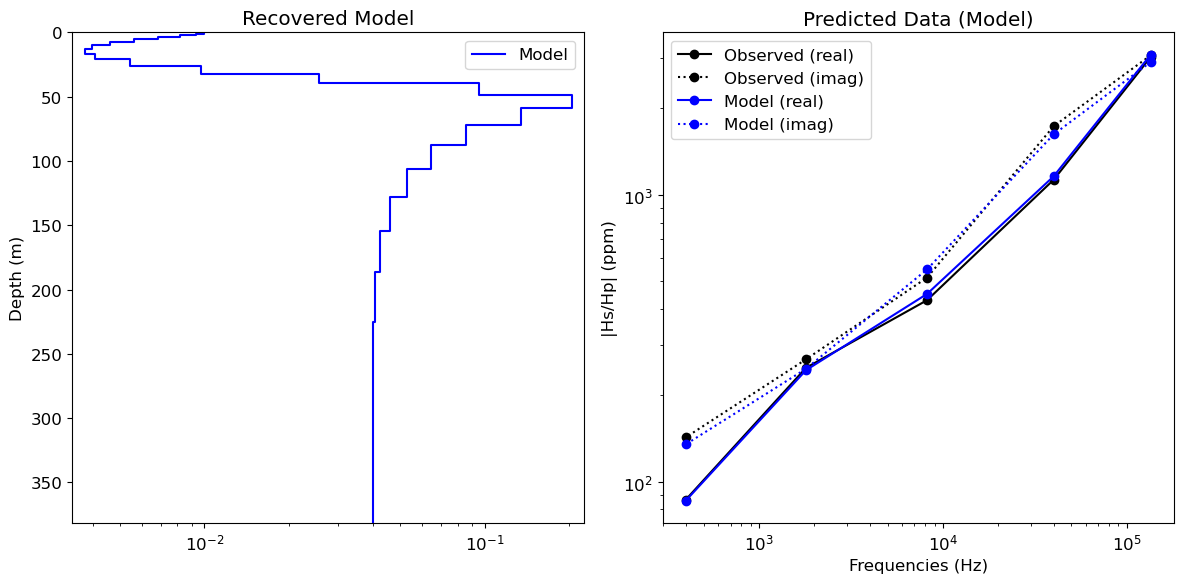

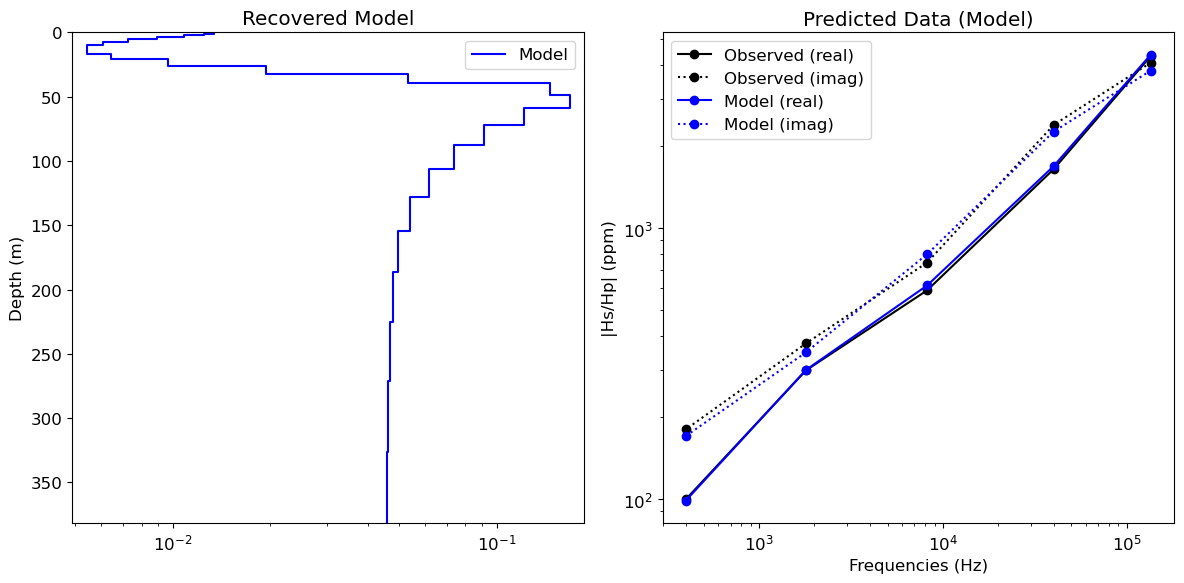

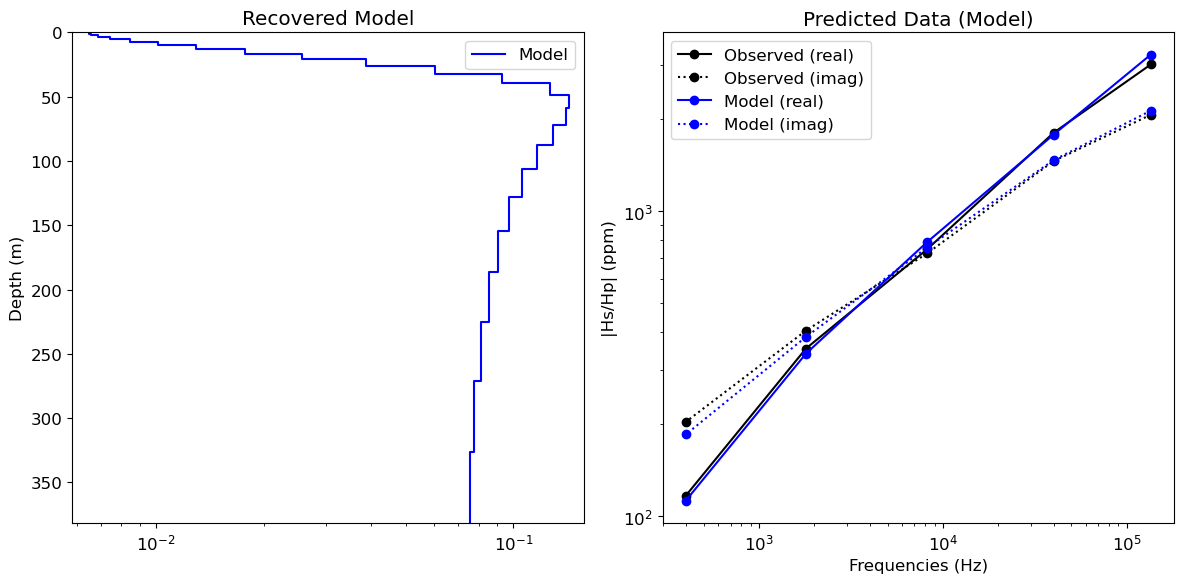

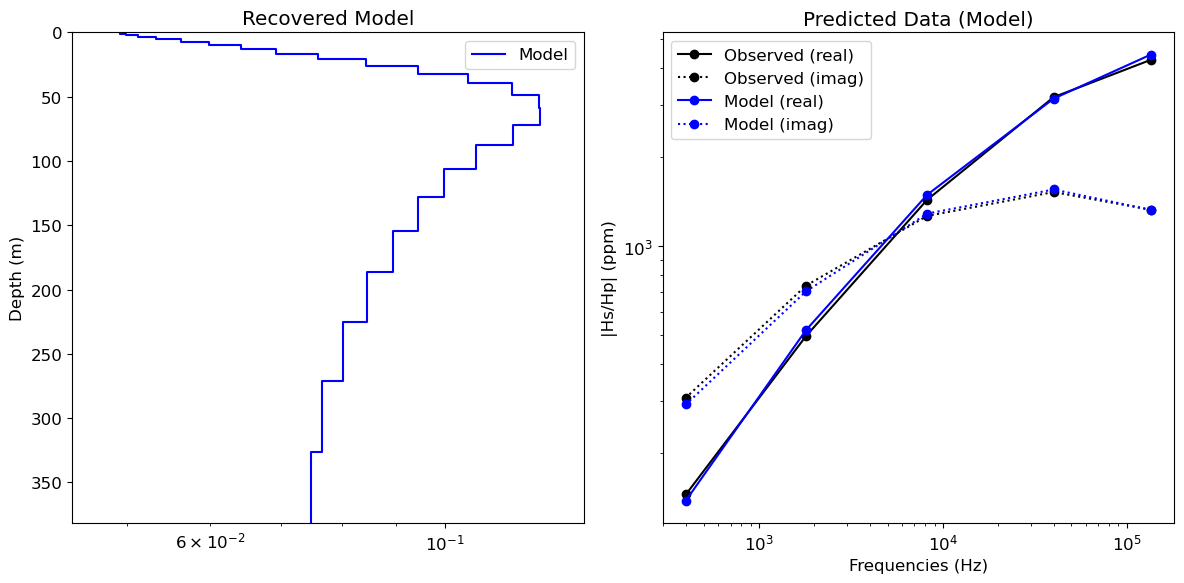

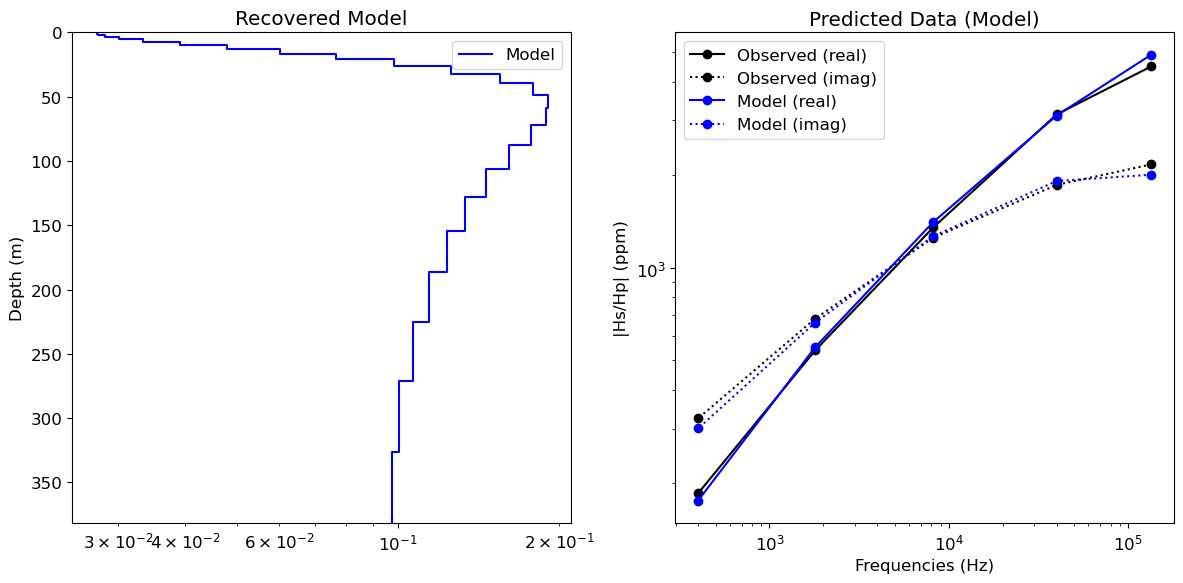

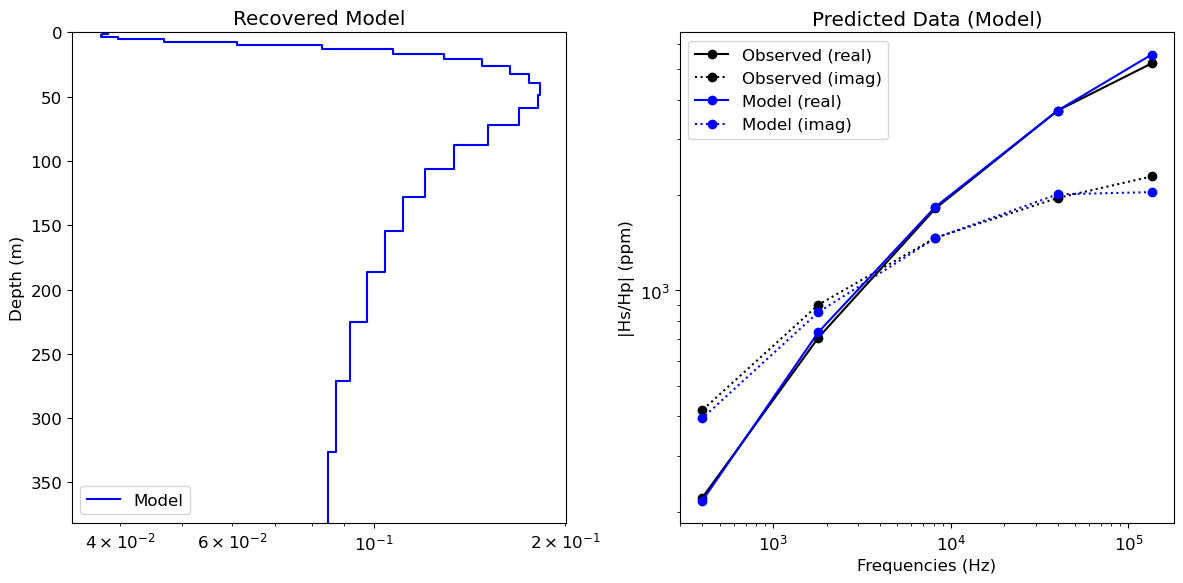

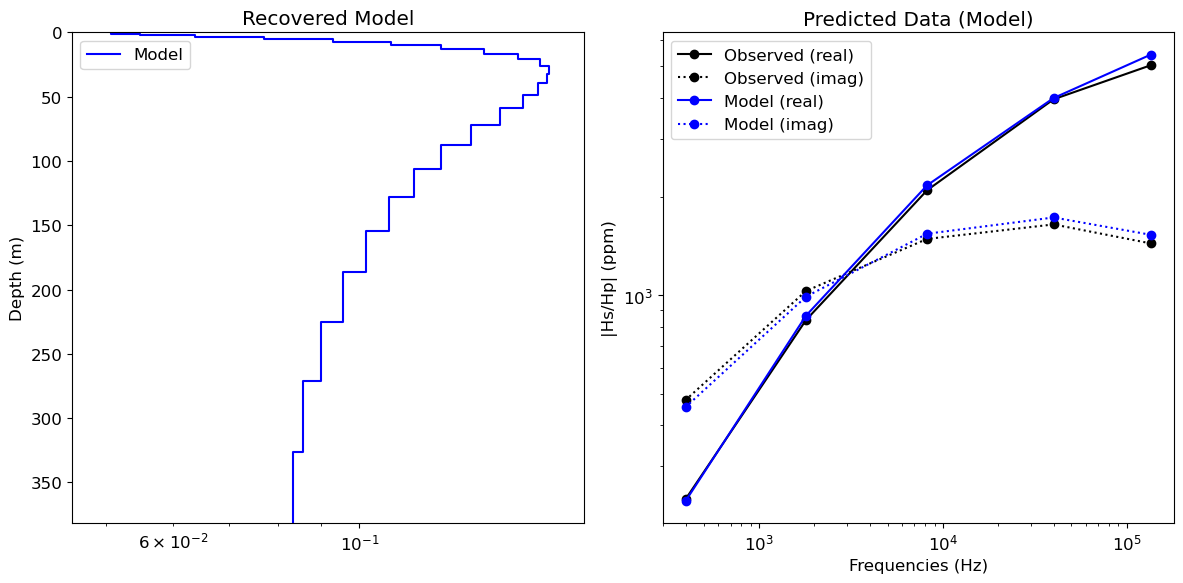

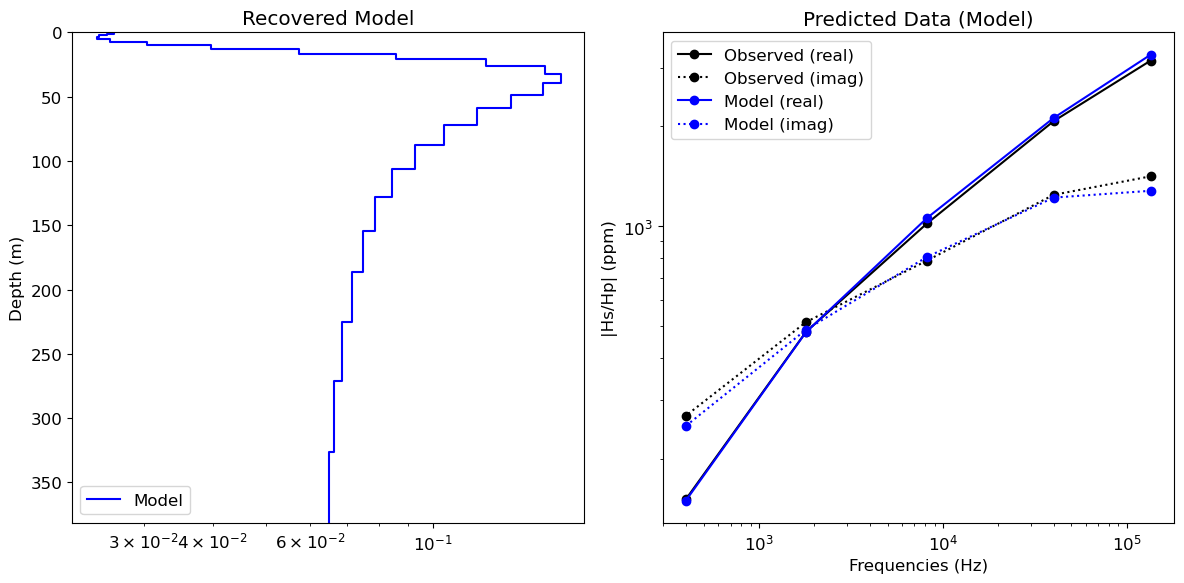

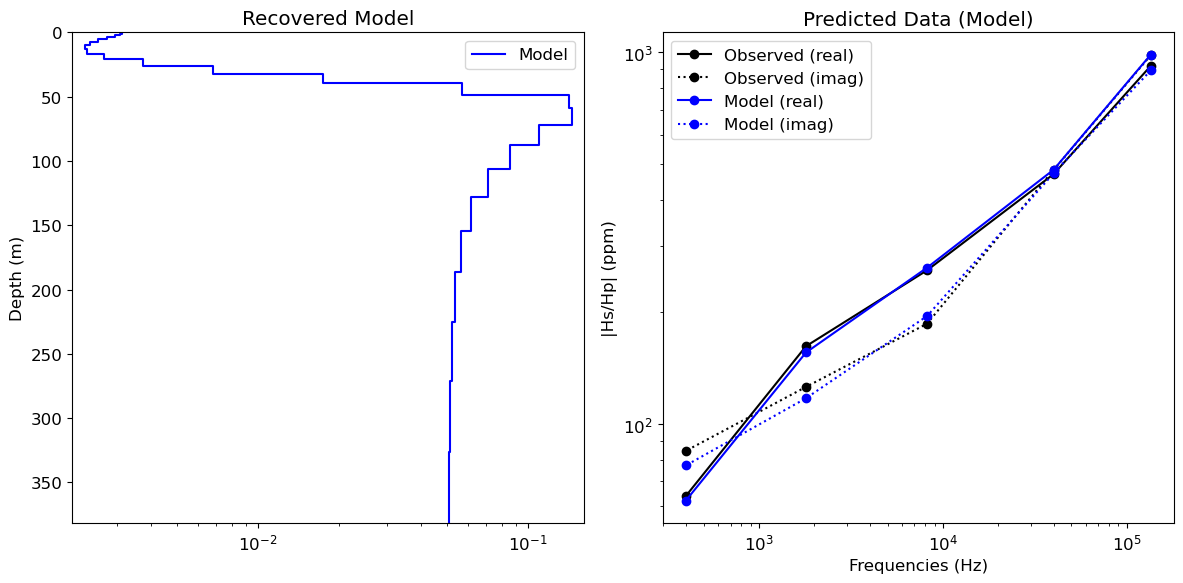

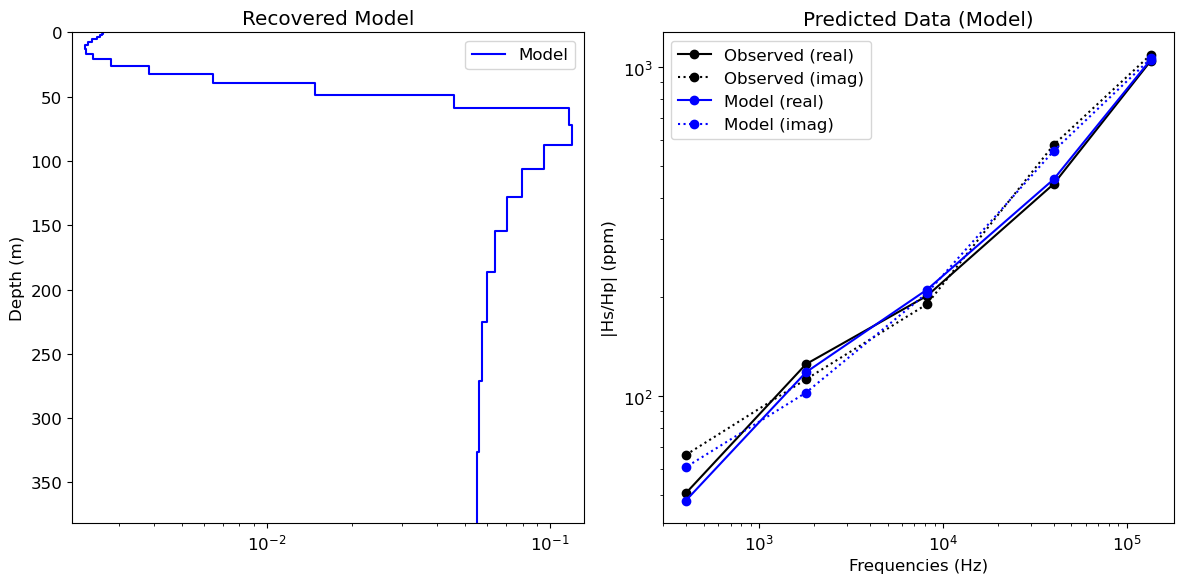

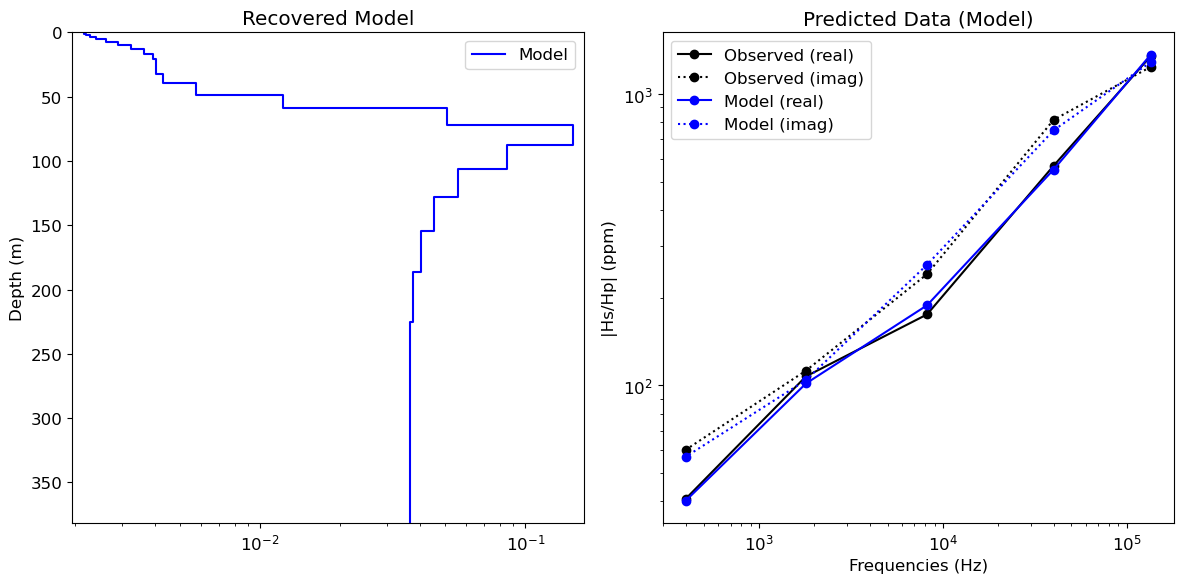

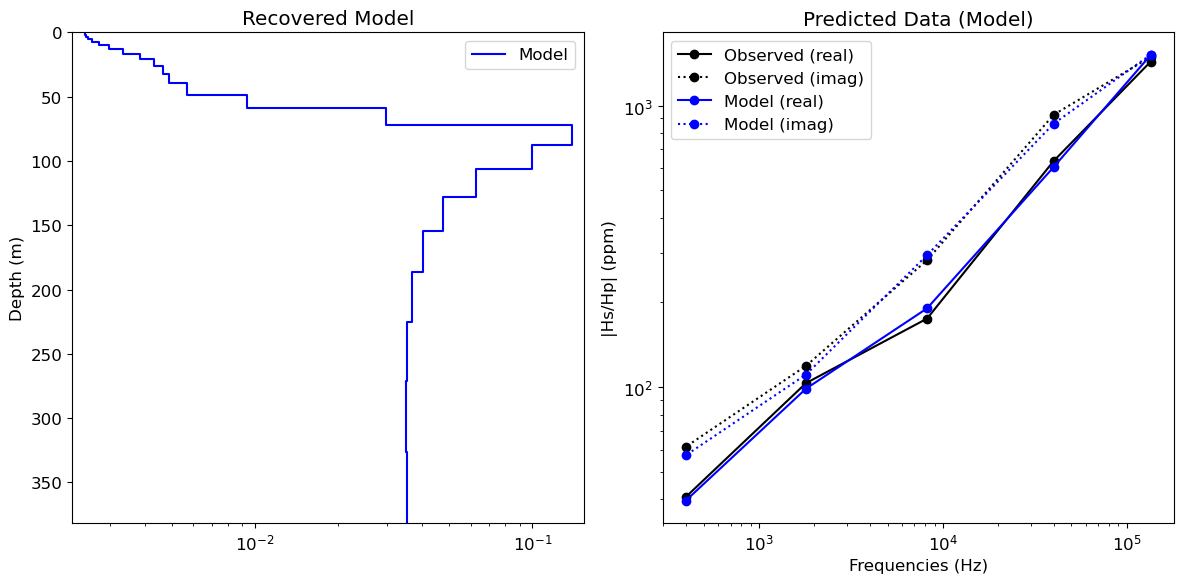

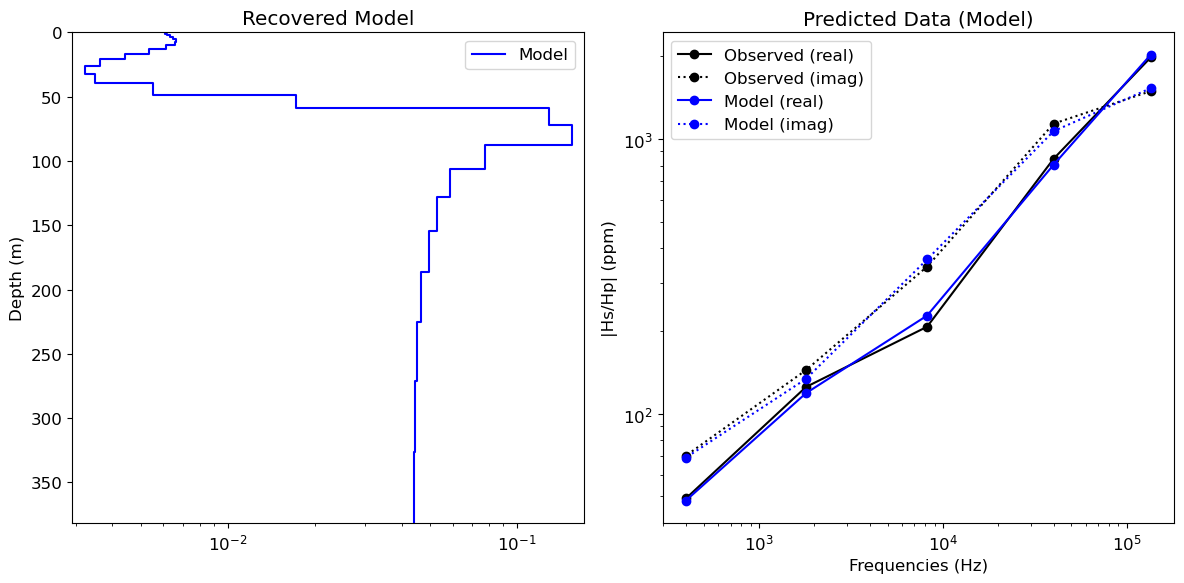

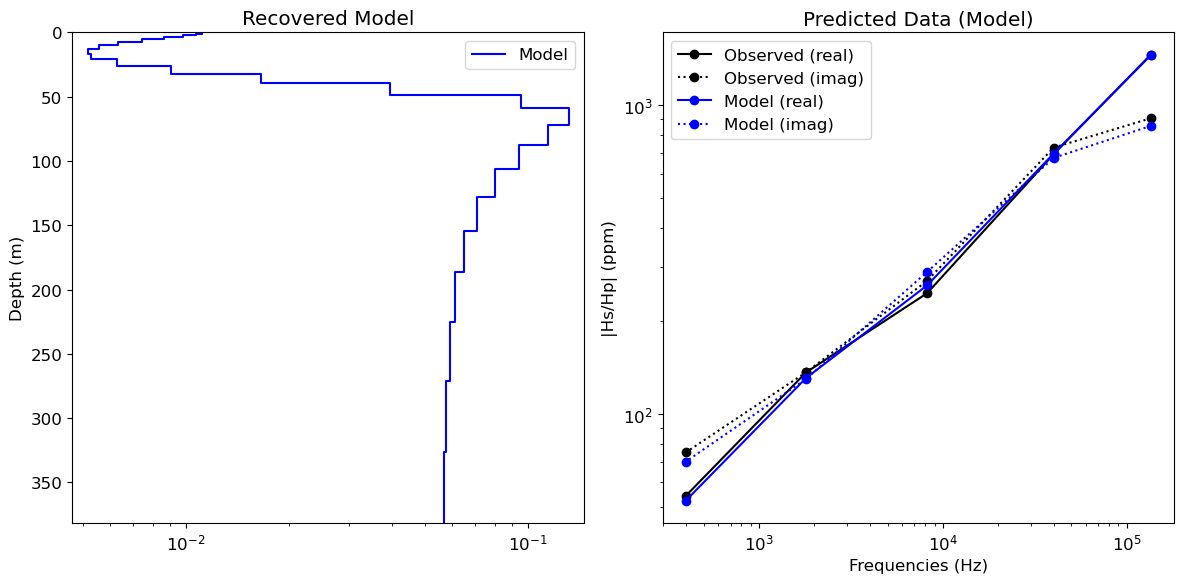

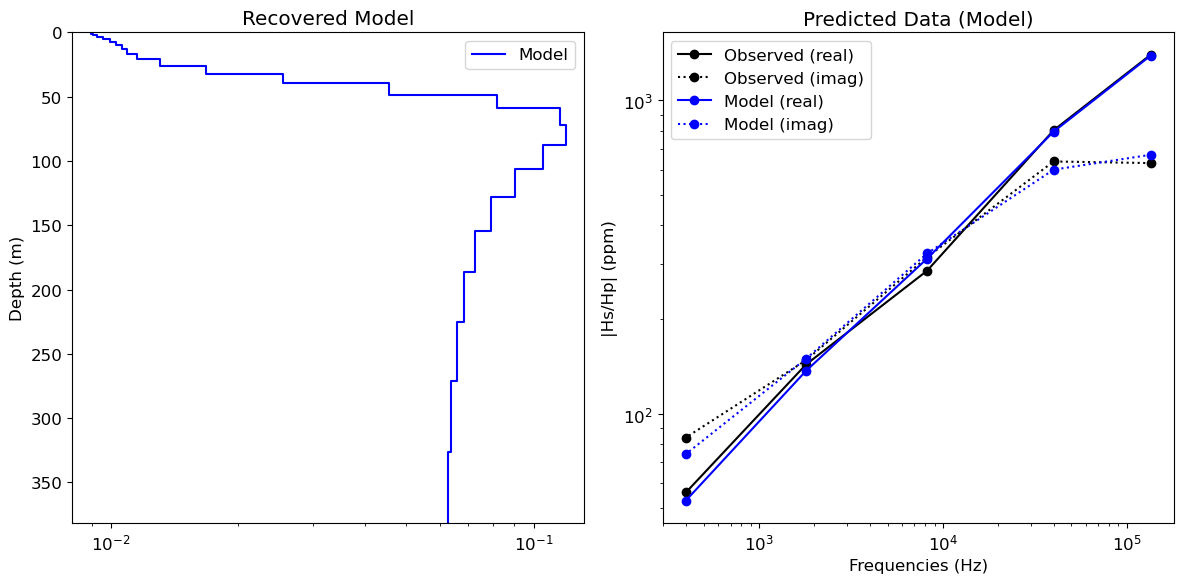

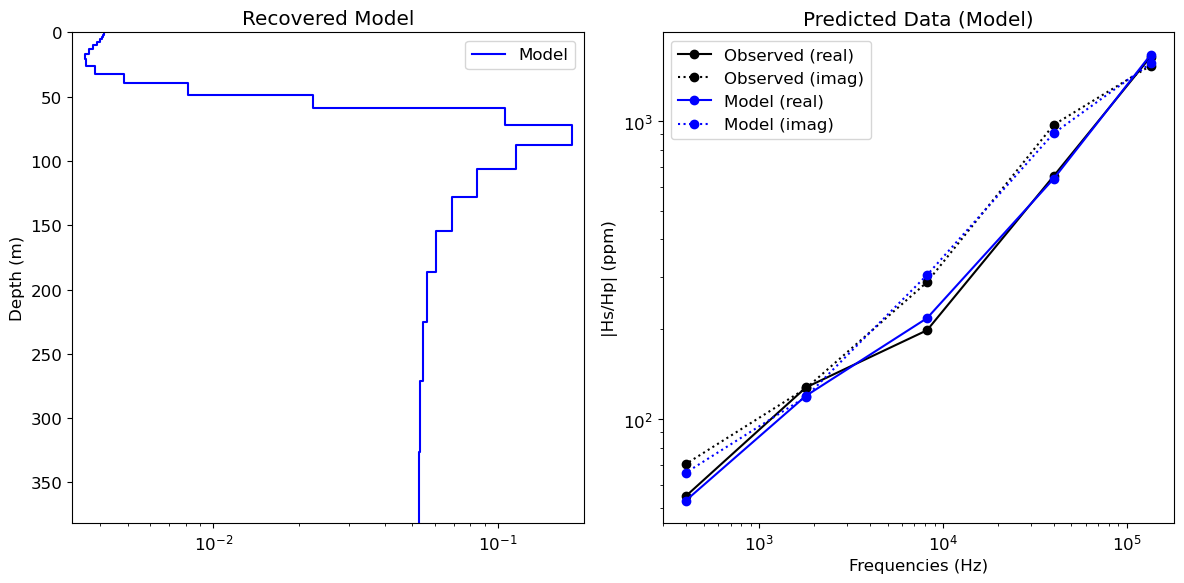

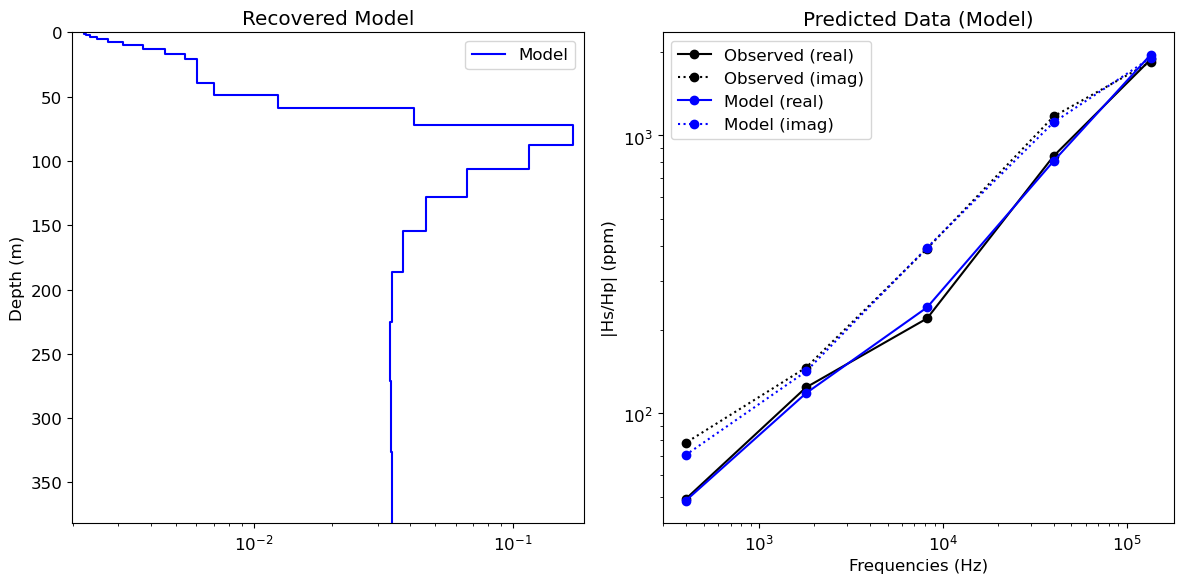

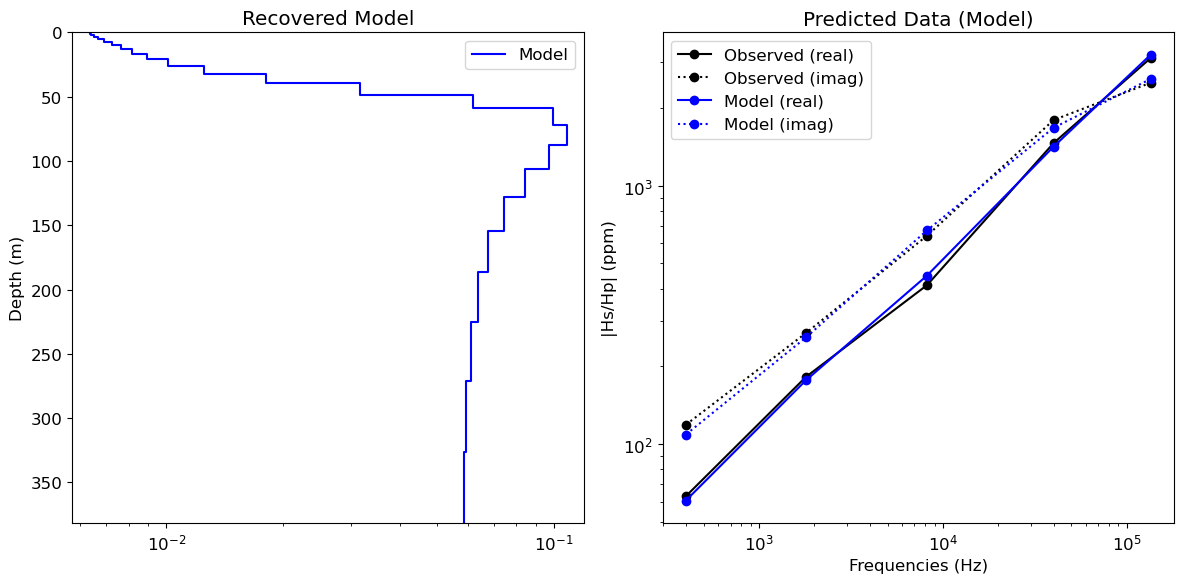

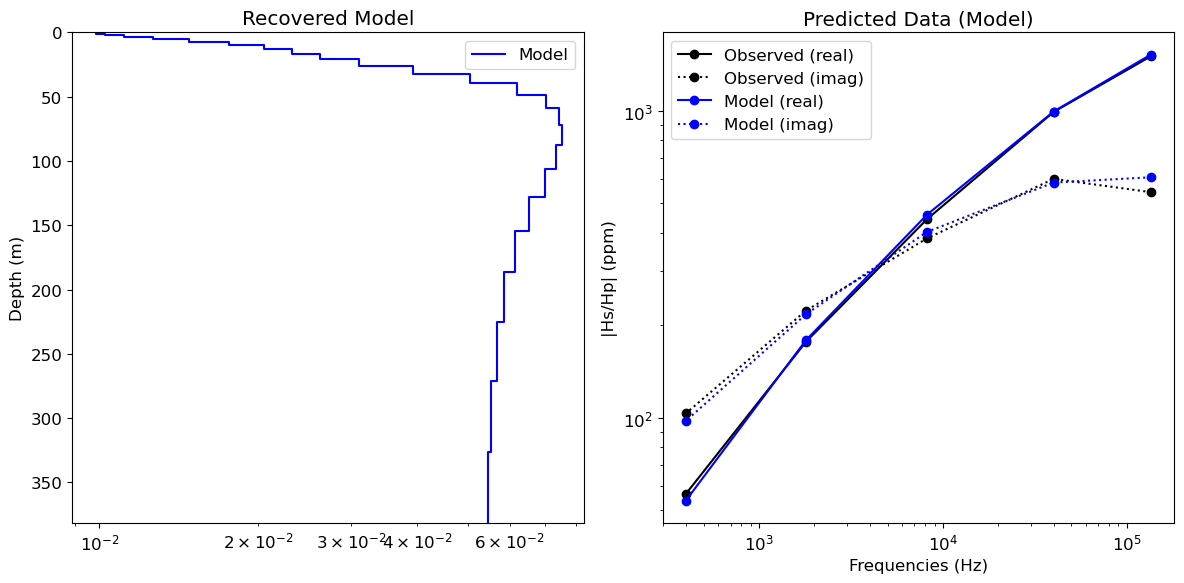

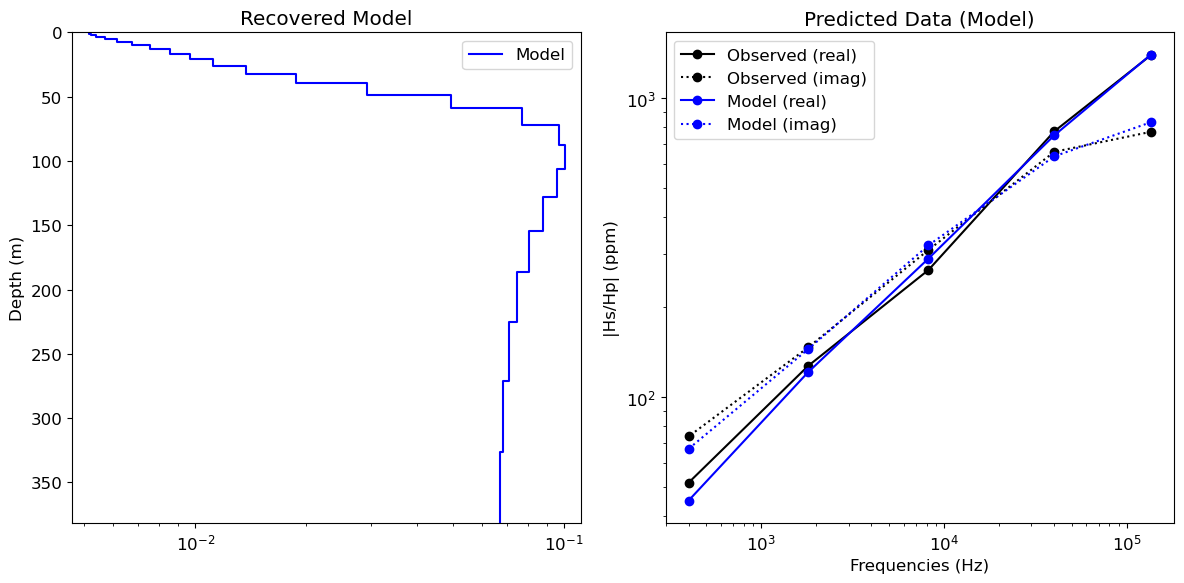

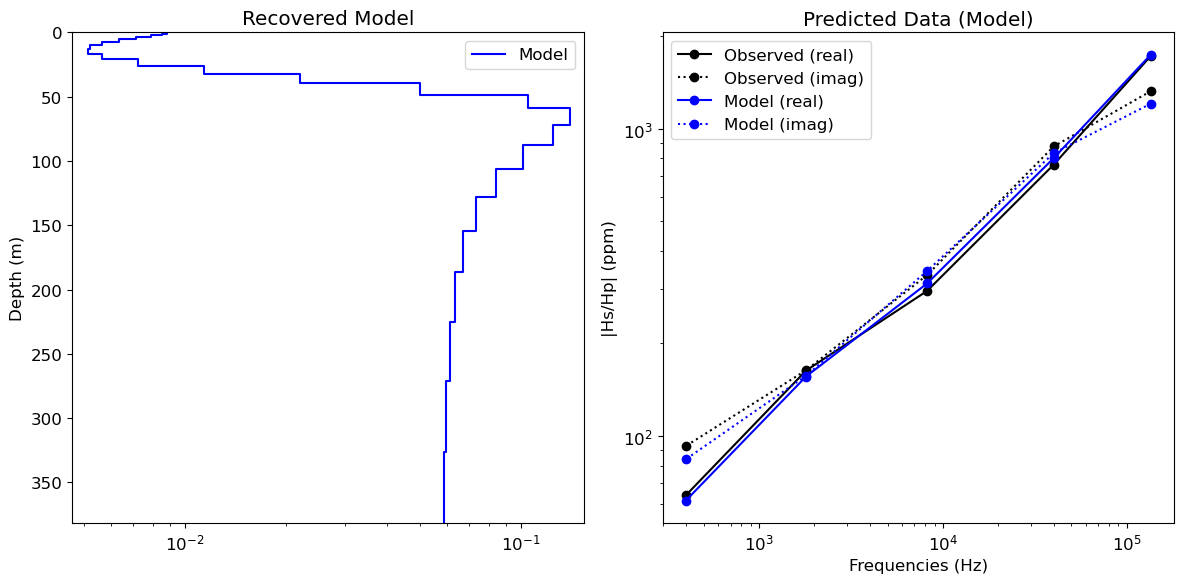

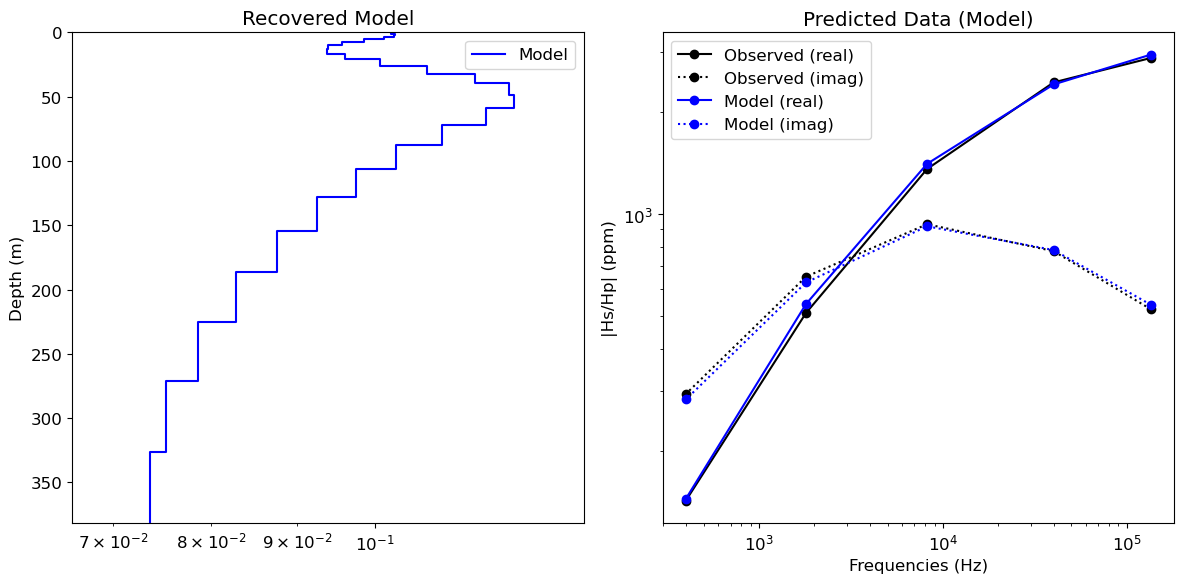

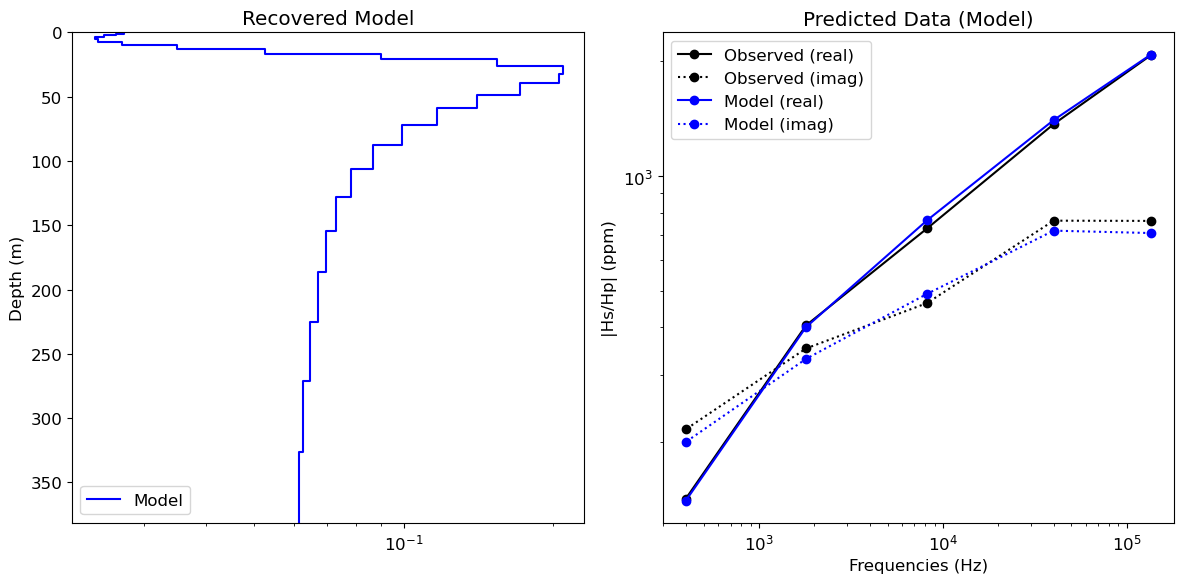

In [11]:
for conductivities_L2, dpred_L2, dobs_L2 in zip(conductivities_soundings, dpred_soundings, dobs_soundings):

    data_functions.plot_inv_results(regularization_mesh_L2, conductivities_L2, dpred_L2, dobs=dobs_L2)
    

In [13]:
inv_prob.phi_d_last

12.05197494211806

# Calculate mean Beta value

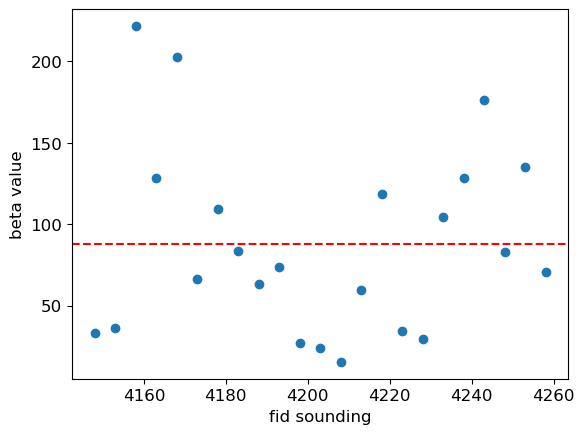

Average beta:  88.01556574360623


In [15]:
# Compute and plot the average
avg_beta = np.mean(beta_approxs)

# Your data
plt.scatter(line_betas, beta_approxs)
plt.axhline(y=avg_beta, color='r', linestyle='--', label=f"avg β = {avg_beta:.2e}")

plt.xlabel("fid sounding")
plt.ylabel("beta value")
plt.show()

print("Average beta: ",avg_beta)

# Sparse Inversion Betas Approx

In [17]:
%%capture
# Save beta values
beta_approxs_Sp = []

#Save the conductivities:
conductivities_soundings_Sp = []

#Save data predicted
dpred_soundings_Sp = []

#Save data observed: 
dobs_soundings_Sp = []

# Loop through the line_betas with the inversion process
for fid_n in line_betas:

    # Choose sounding station with the given fid_n
    line_station = line.loc[line.fid == fid_n].iloc[0]

    #Run inversion with sparse_inversion.py
    regularization_mesh_Sp, log_conductivity_Sp_map, simulation_Sp, inv_Sp, inv_prob, recovered_model_Sp, conductivities_Sp, data_object_Sp = sparse_inversion.sparse_inversion(line_station, conductivities_hsp, depth_max = depth_max, inv_prob_return = True)
    
    #Get the beta schedule from the inversion
    beta_approxs_Sp.append(inv_prob.beta)

    #Save the conductivities values:
    conductivities_soundings_Sp.append(conductivities_Sp)

    #Save the data predicted values
    dpred_soundings_Sp.append(simulation_Sp.dpred(recovered_model_Sp))

    #Save data observed:
    dobs_soundings_Sp.append(data_object_Sp.dobs)

# Plot Inversion results

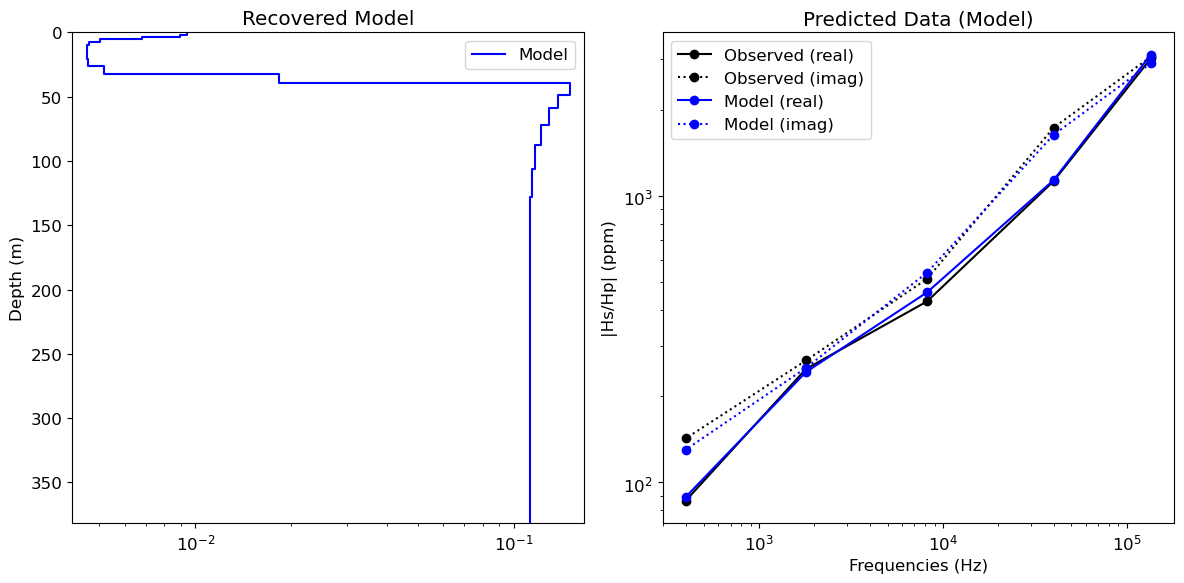

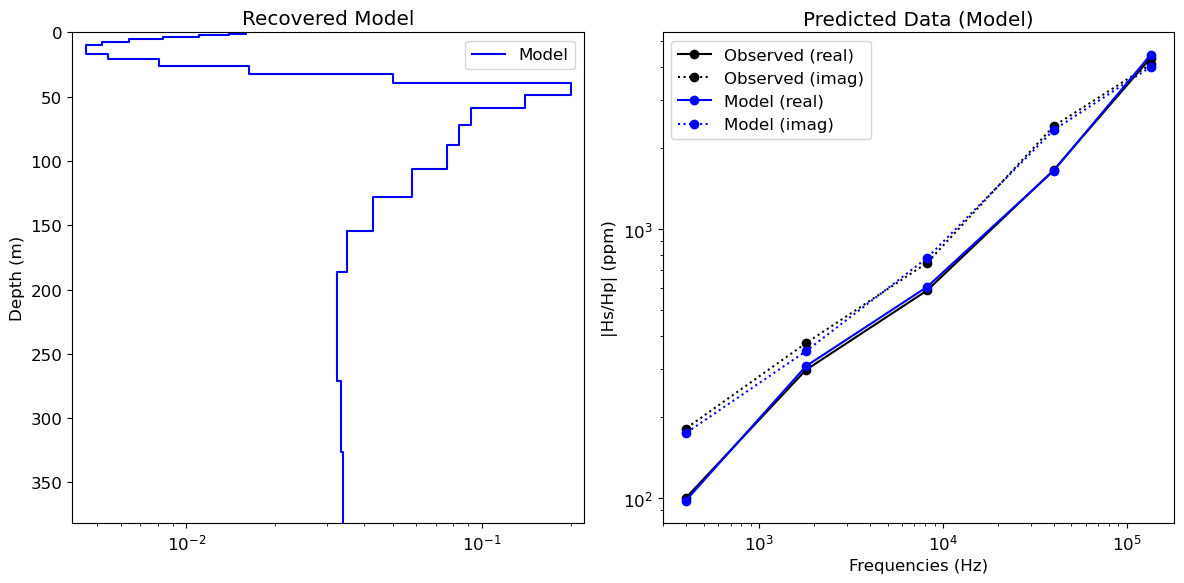

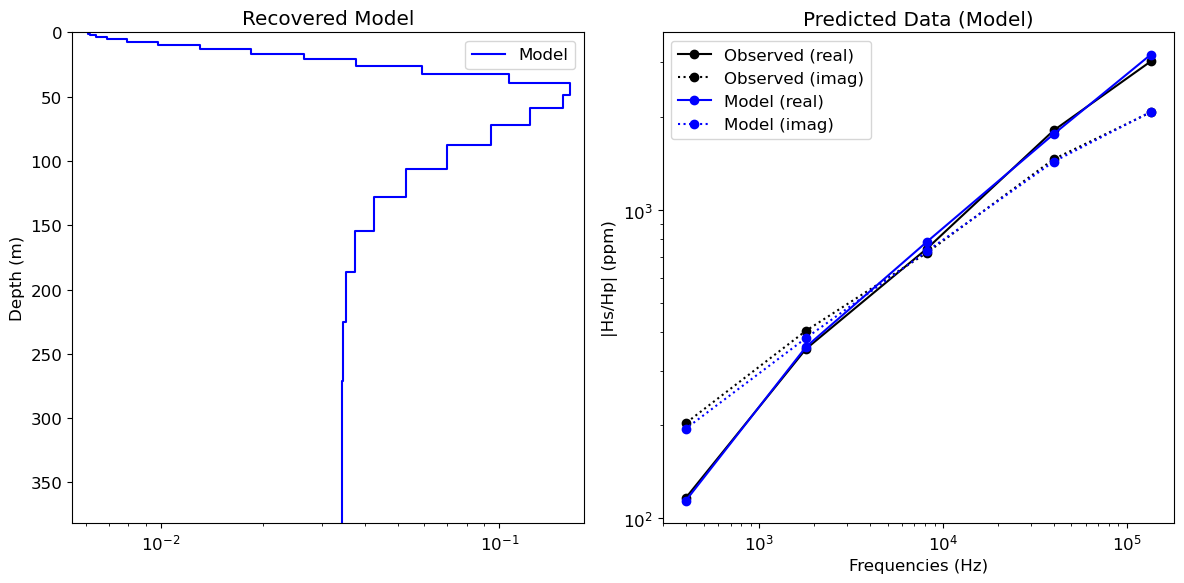

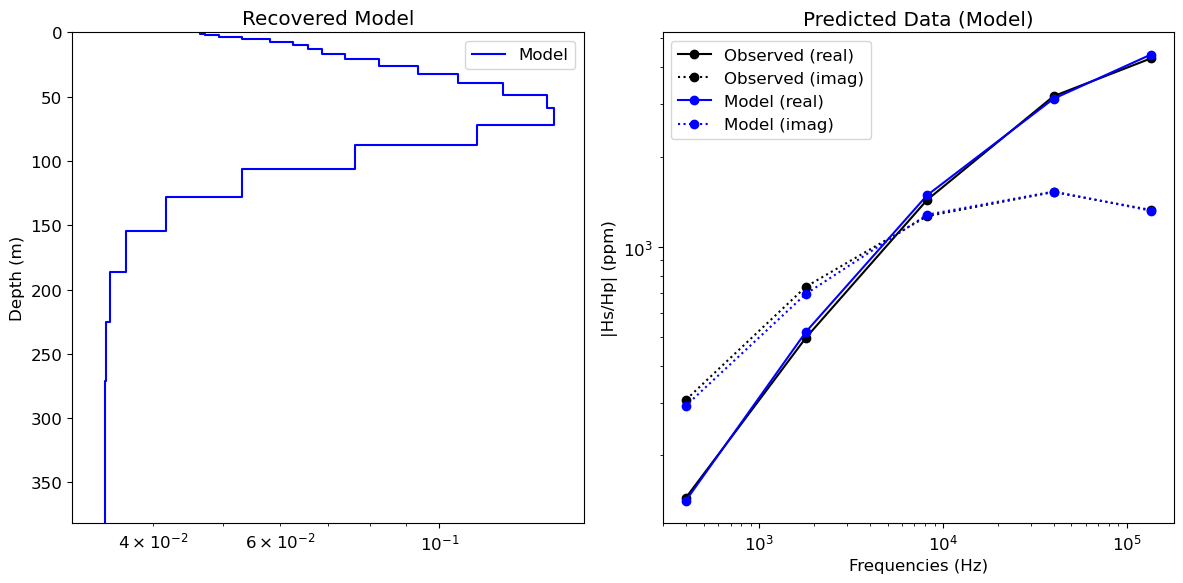

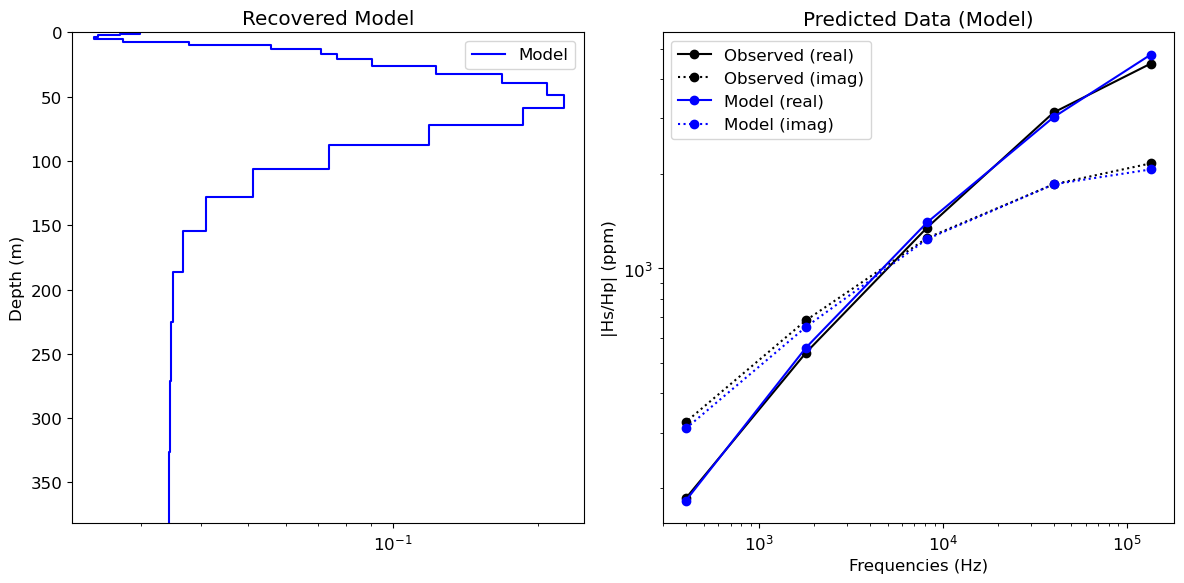

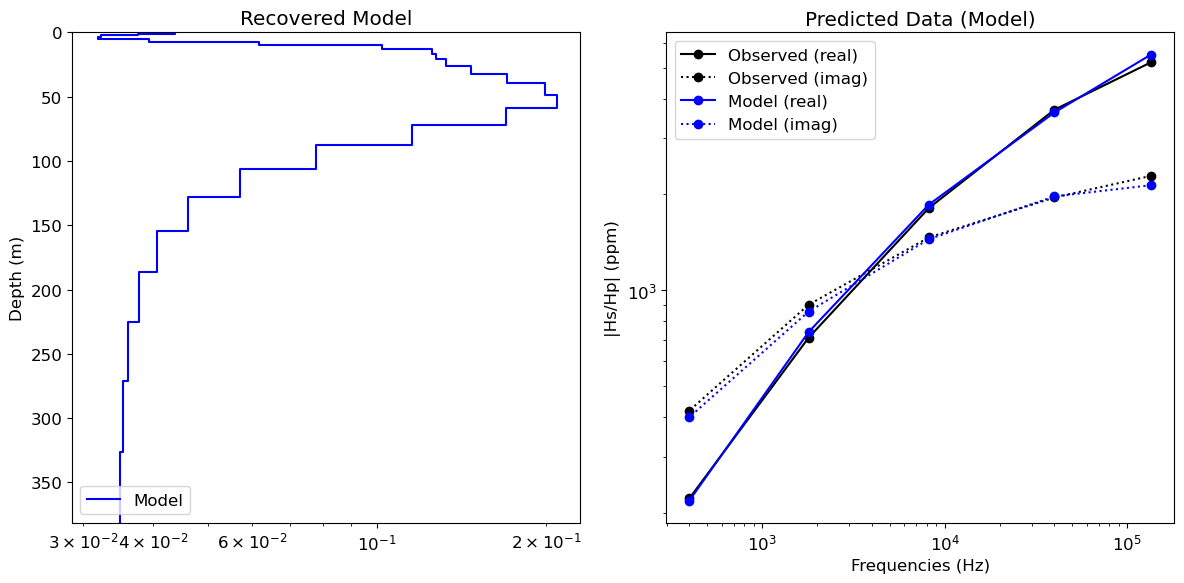

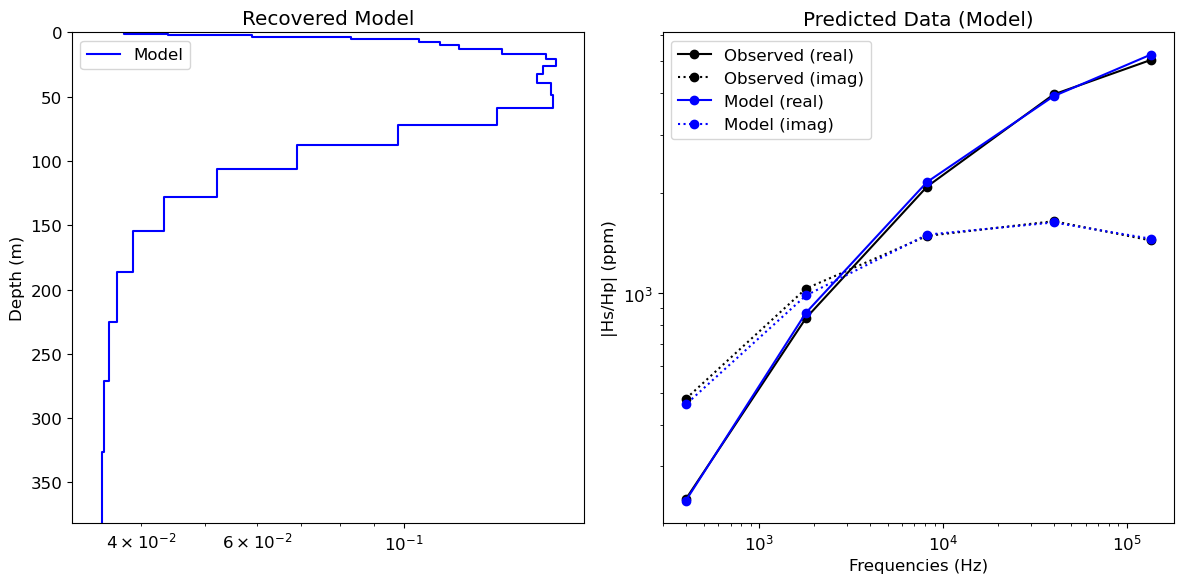

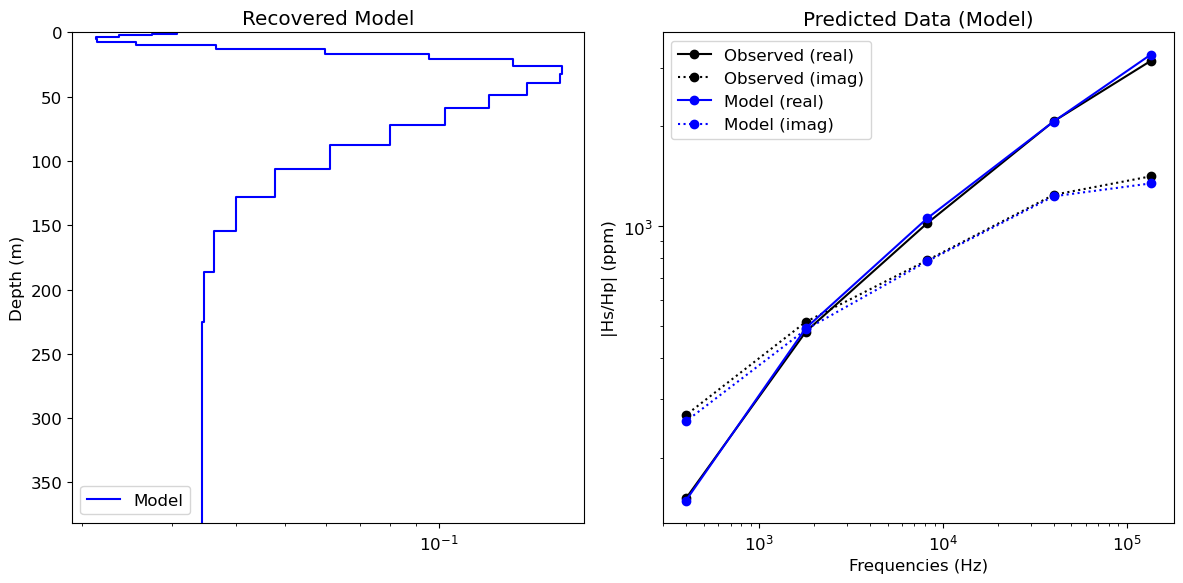

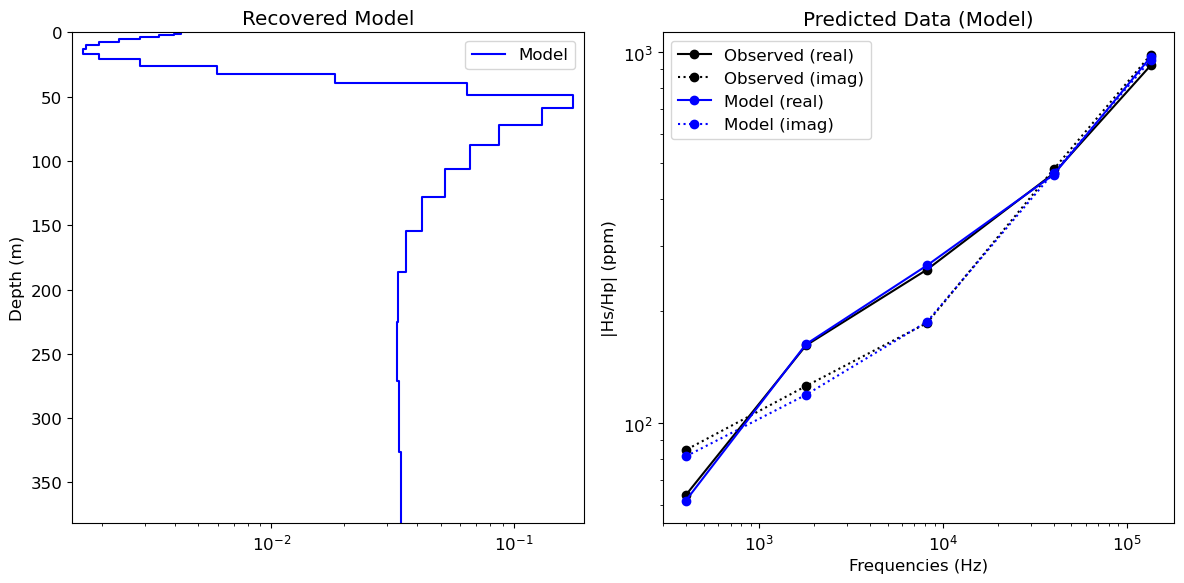

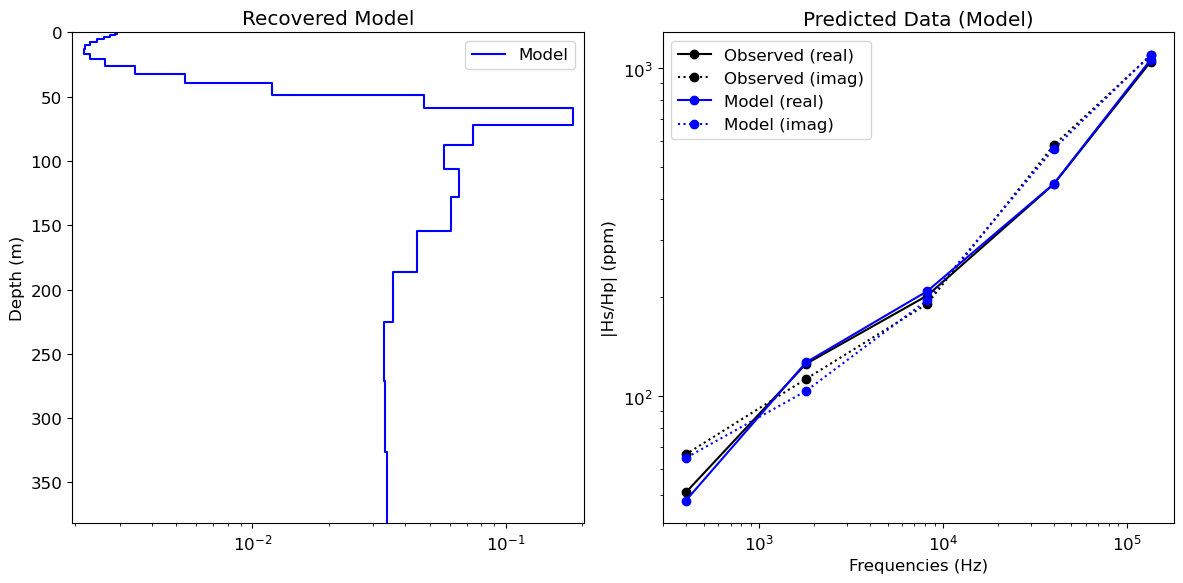

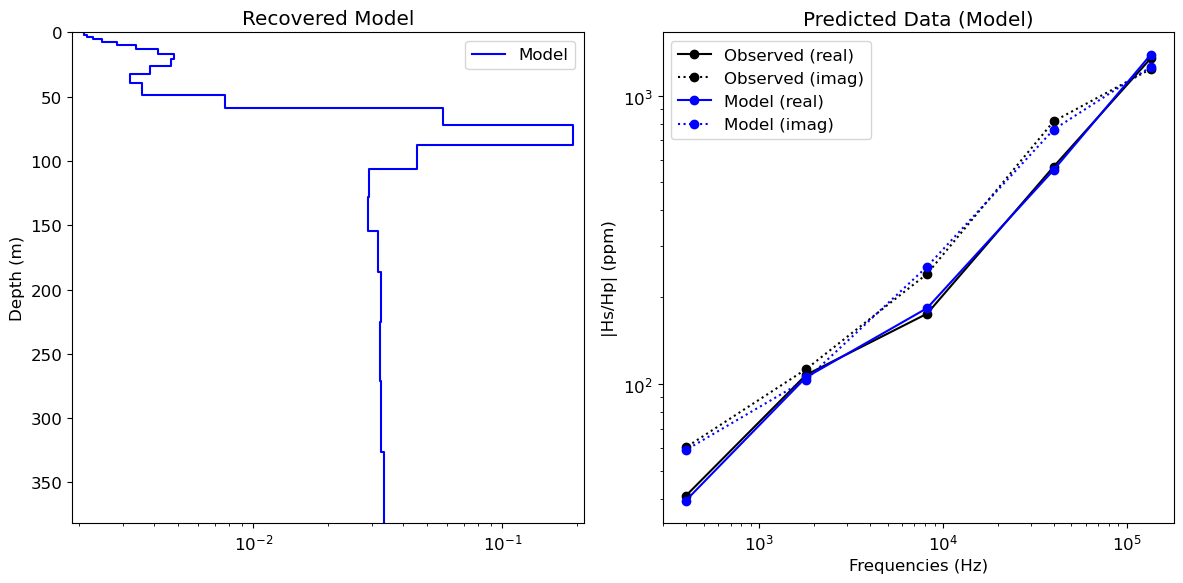

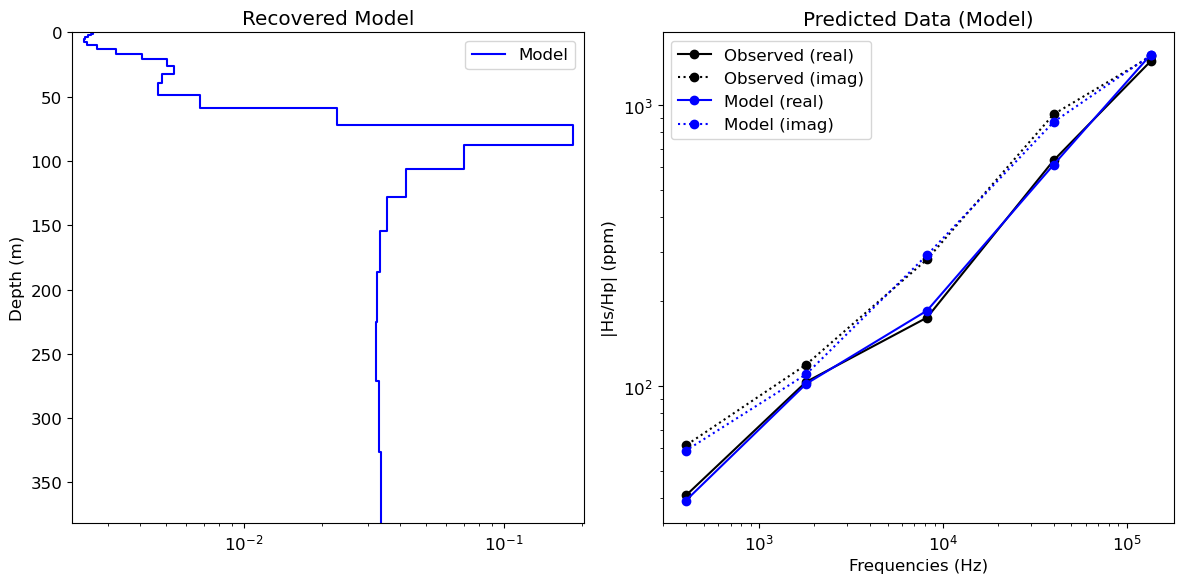

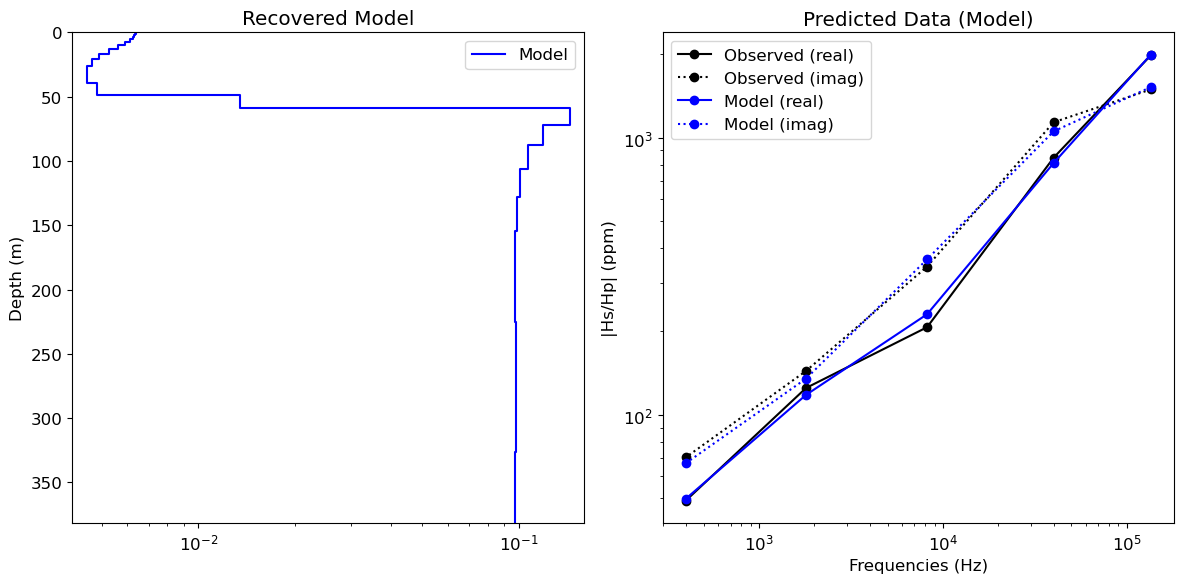

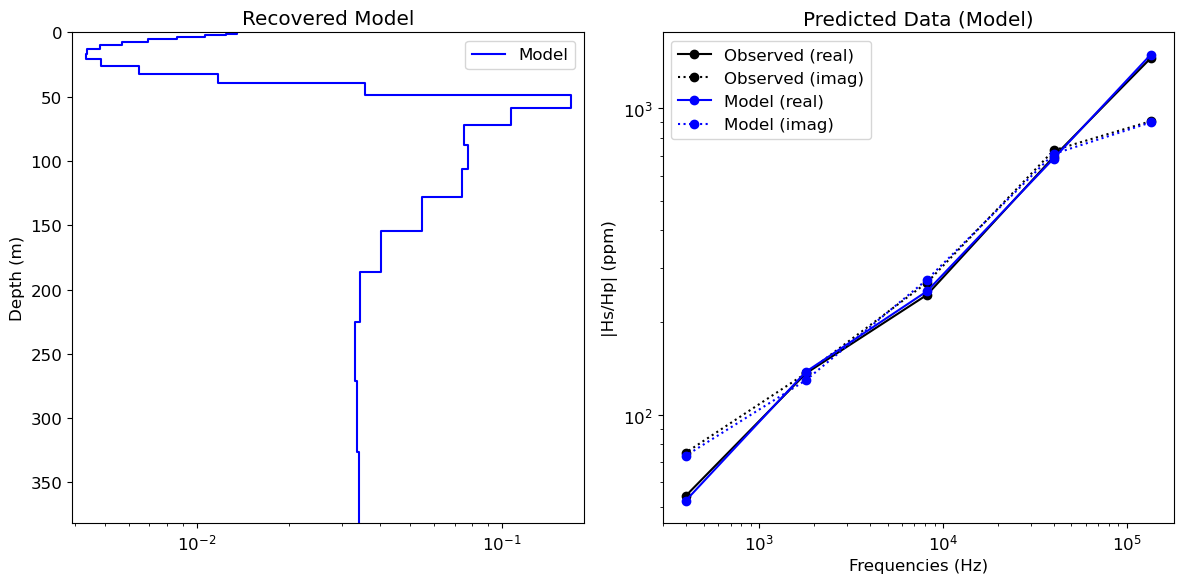

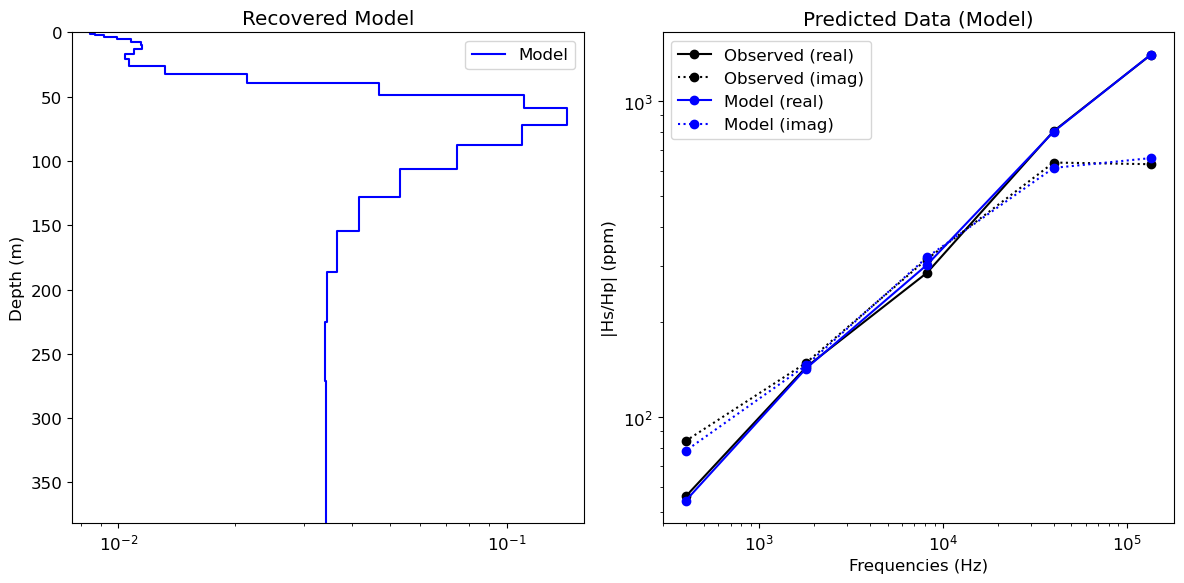

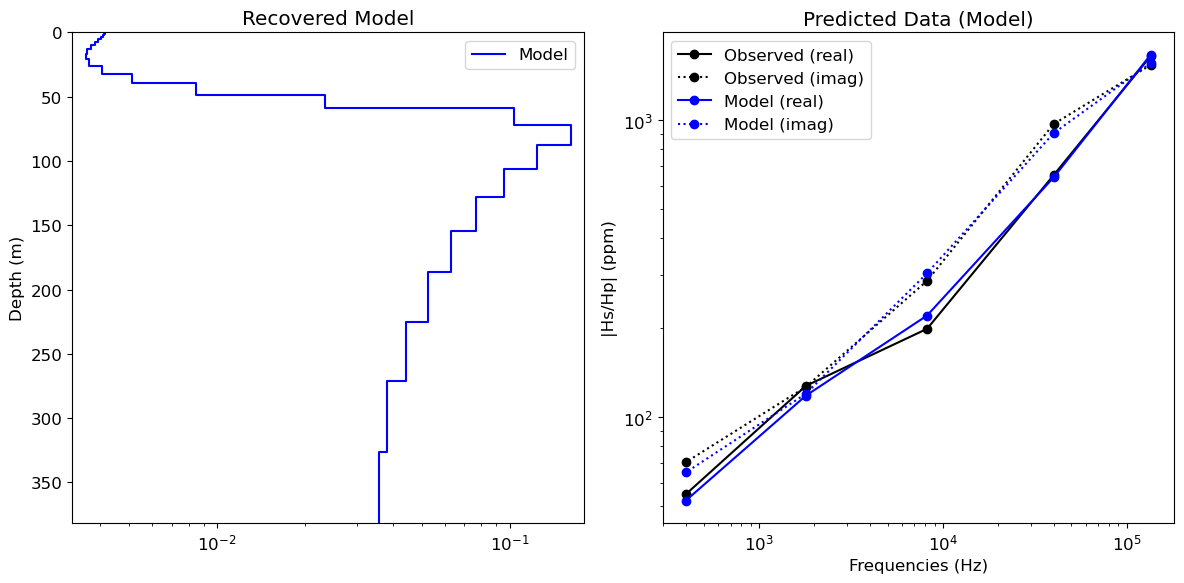

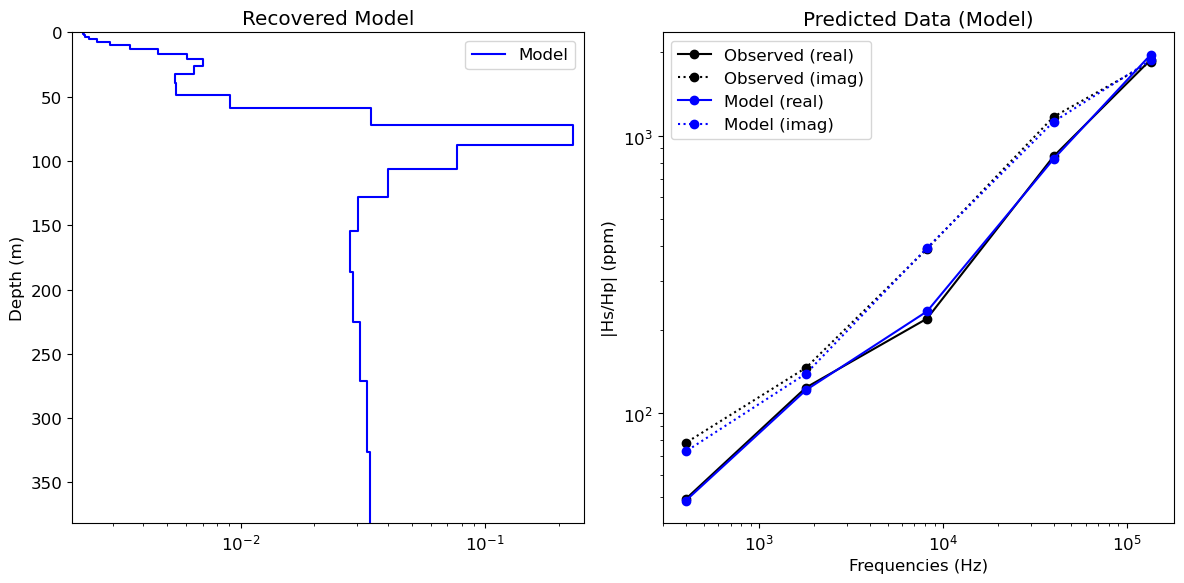

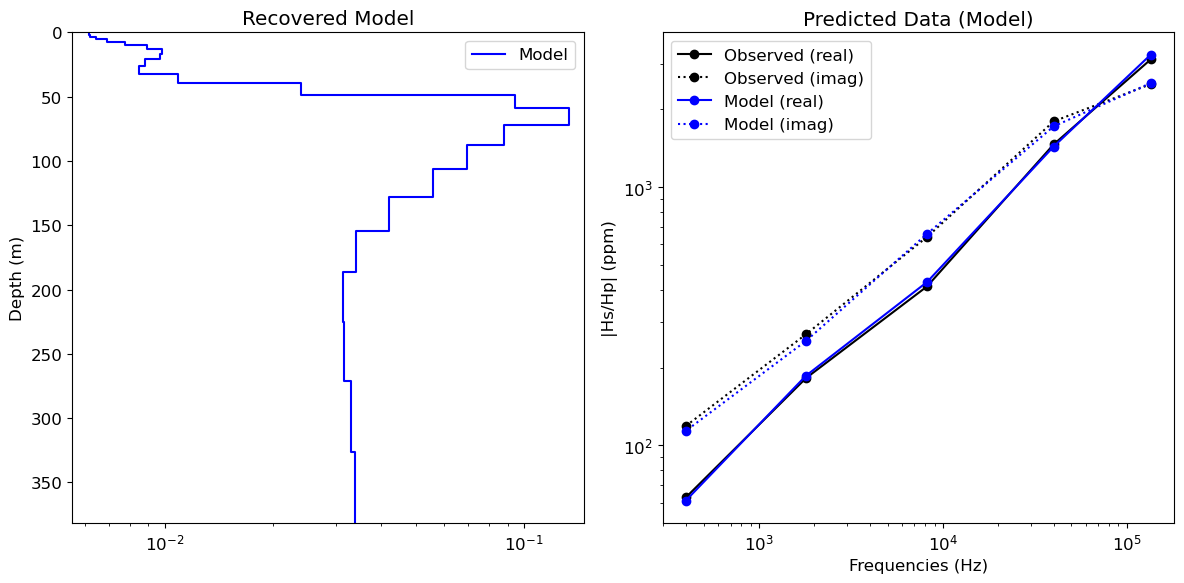

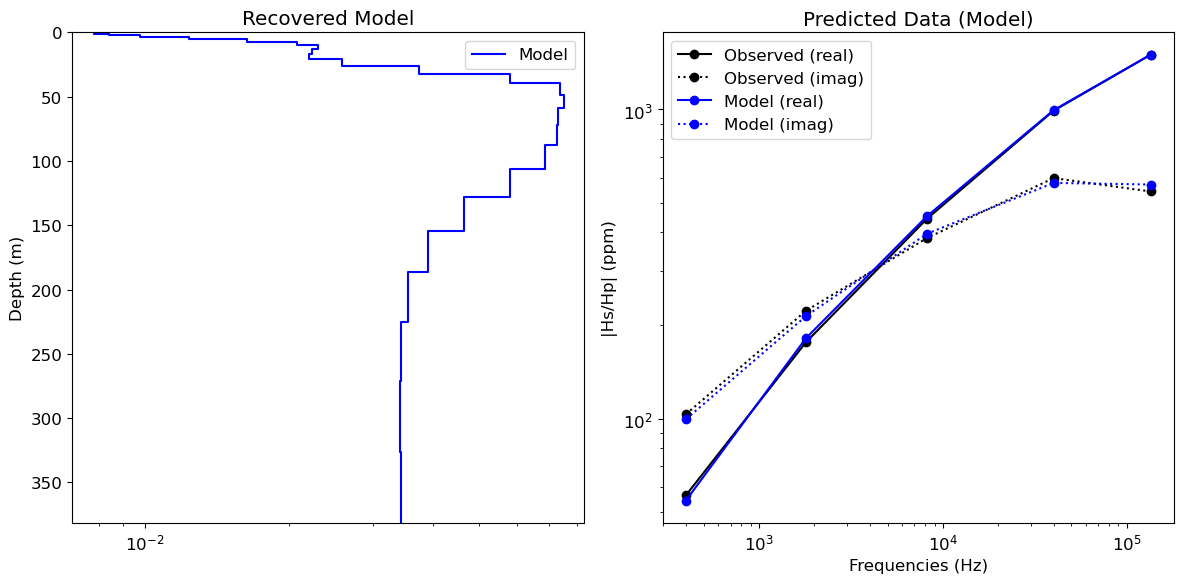

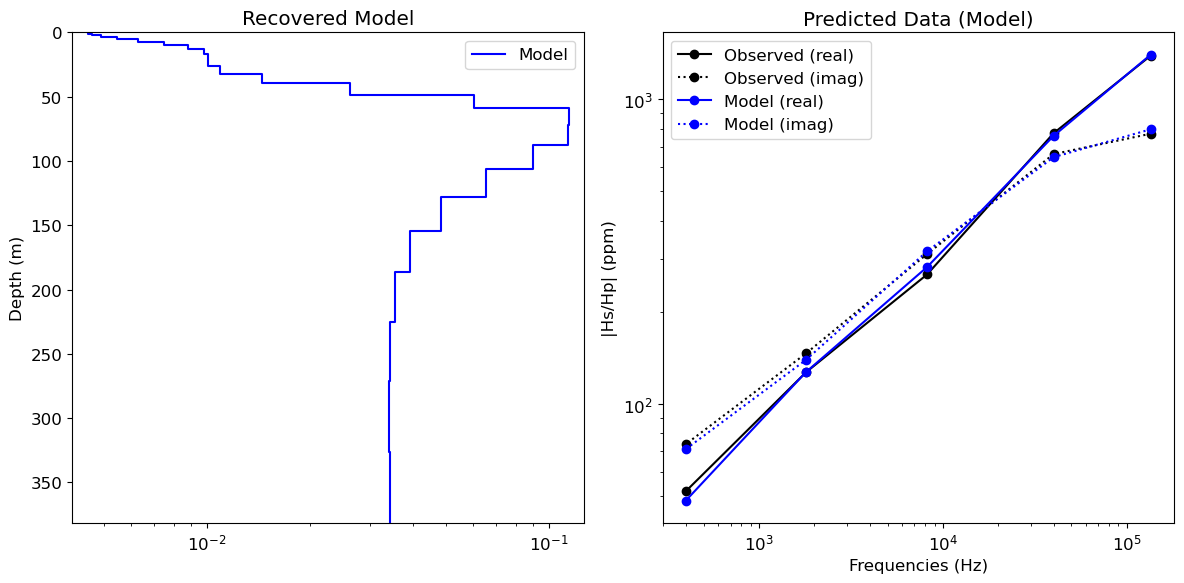

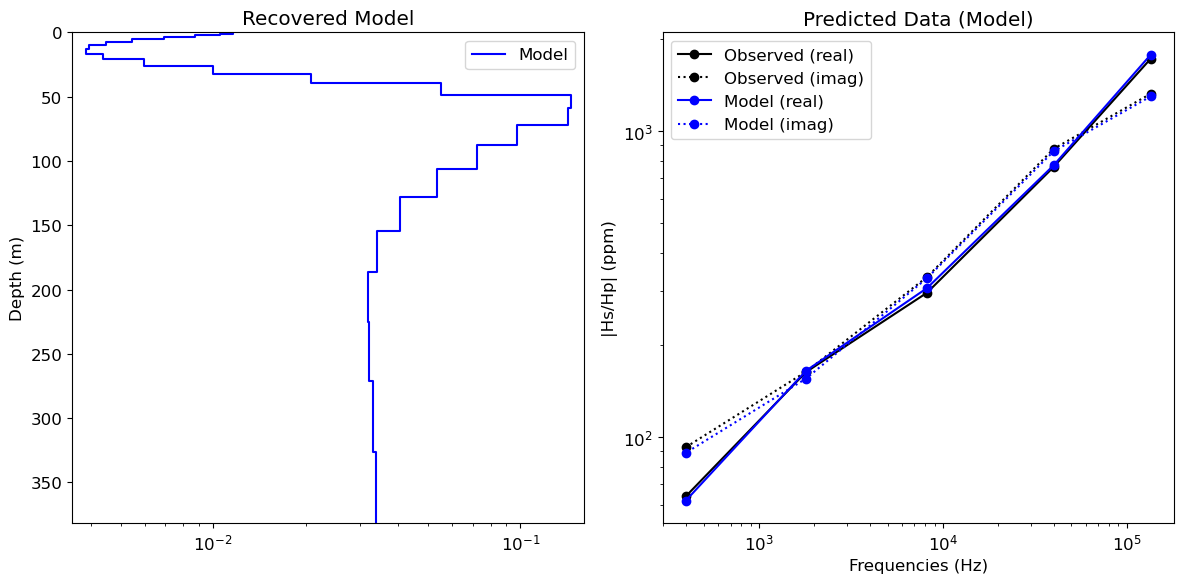

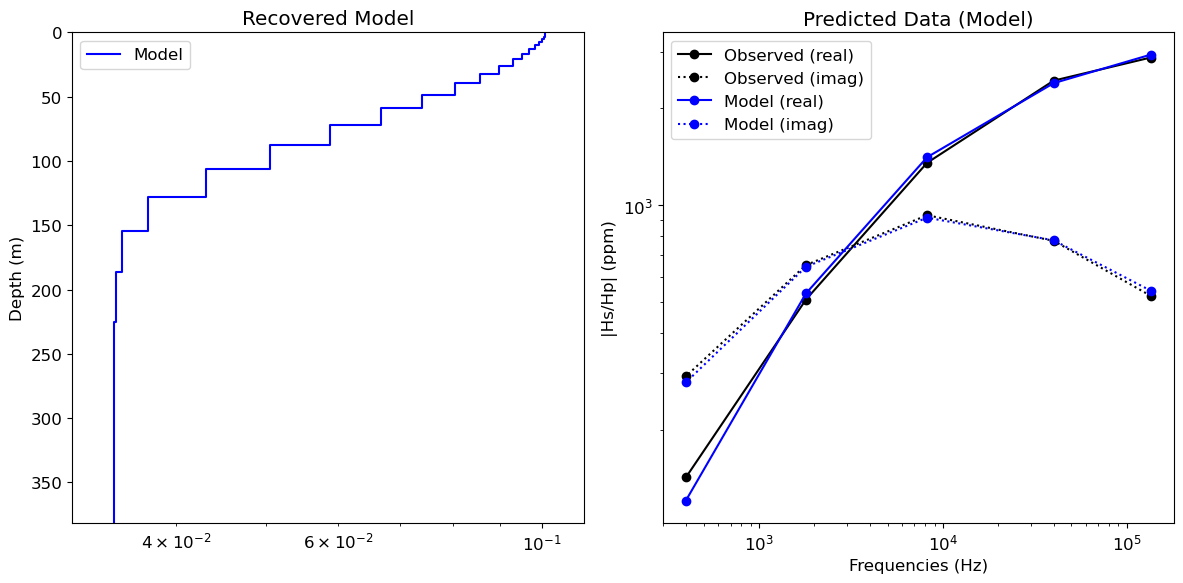

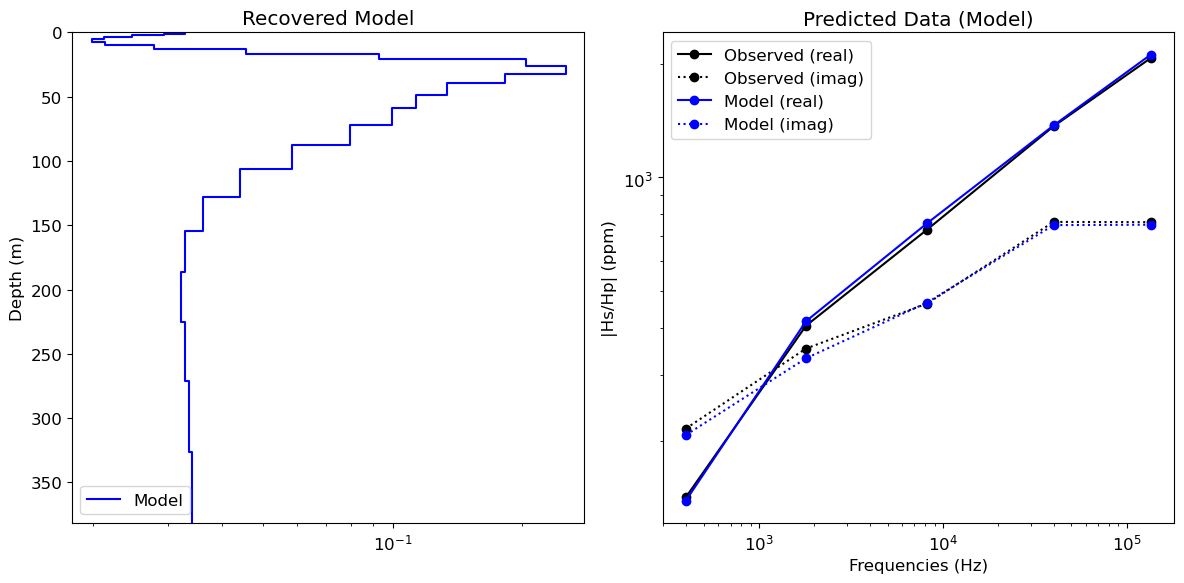

In [19]:
for conductivities_Sp, dpred_Sp, dobs_Sp in zip(conductivities_soundings_Sp, dpred_soundings_Sp, dobs_soundings_Sp):

    data_functions.plot_inv_results(regularization_mesh_Sp, conductivities_Sp, dpred_Sp, dobs= dobs_Sp)
    

# Calculate mean Beta value

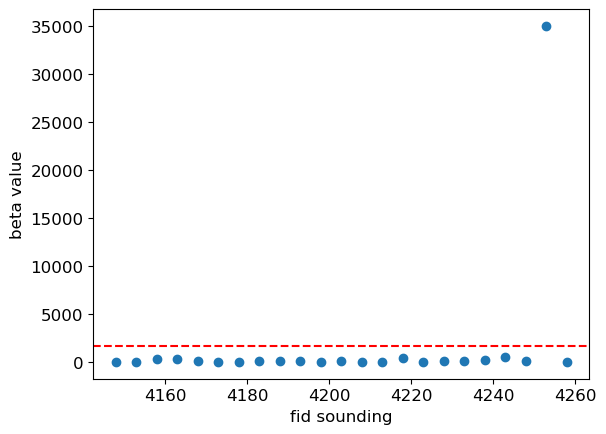

Average beta:  1650.8050731672772


In [21]:
# Compute and plot the average
avg_beta_Sp = np.mean(beta_approxs_Sp)

# Your data
plt.scatter(line_betas, beta_approxs_Sp)
plt.axhline(y=avg_beta_Sp, color='r', linestyle='--', label=f"avg β = {avg_beta:.2e}")

plt.xlabel("fid sounding")
plt.ylabel("beta value")
plt.show()

print("Average beta: ",avg_beta_Sp)

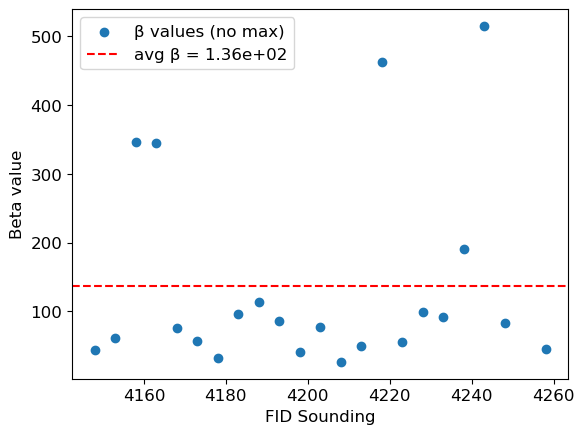

Average beta without max: 136.25724375925387


In [22]:
# Filter out outlier:

# Convert to NumPy array
beta_values = np.array(beta_approxs_Sp)
fids = np.array(line_betas)

# Find index of the max value
max_idx = np.argmax(beta_values)

# Remove the max value from both arrays
filtered_betas = np.delete(beta_values, max_idx)
filtered_fids = np.delete(fids, max_idx)

# Compute the average
avg_beta_filtered = np.mean(filtered_betas)

# Plot
plt.scatter(filtered_fids, filtered_betas, label="β values (no max)")
plt.axhline(y=avg_beta_filtered, color='r', linestyle='--', label=f"avg β = {avg_beta_filtered:.2e}")

plt.xlabel("FID Sounding")
plt.ylabel("Beta value")
plt.legend()
plt.show()

print("Average beta without max:", avg_beta_filtered)


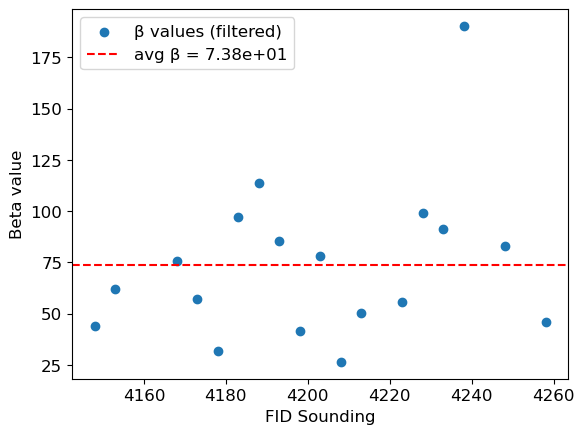

Average beta (filtered): 73.77449749816479


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to NumPy arrays
beta_values = np.array(beta_approxs_Sp)
fids = np.array(line_betas)

# Compute IQR
q1 = np.percentile(beta_values, 25)
q3 = np.percentile(beta_values, 75)
iqr = q3 - q1

# Define lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter out values outside the bounds
mask = (beta_values >= lower_bound) & (beta_values <= upper_bound)
filtered_betas = beta_values[mask]
filtered_fids = fids[mask]

# Compute average
avg_beta_filtered = np.mean(filtered_betas)

# Plot
plt.scatter(filtered_fids, filtered_betas, label="β values (filtered)")
plt.axhline(y=avg_beta_filtered, color='r', linestyle='--', label=f"avg β = {avg_beta_filtered:.2e}")

plt.xlabel("FID Sounding")
plt.ylabel("Beta value")
plt.legend()
plt.show()

print("Average beta (filtered):", avg_beta_filtered)


In [24]:
#> /dev/null

# ToDos
* Use paralelizations and GPUs